In [6]:
import json
from datetime import datetime
import time

In [7]:
# Imports
import sys
import os
from pathlib import Path
import numpy as np
import pandas as pd
import geopandas as gpd
from tqdm import tqdm
import pickle
import hashlib
import rasterio
from scipy.optimize import root_scalar
from rtree import index
import warnings
warnings.filterwarnings('ignore')
from shapely.geometry import Point, LineString, Polygon

# Add src directory to path
sys.path.append(str(Path.cwd().parent / 'src'))

# Import repo modules
import grid_based_accessibility_hex as grid_hex
#TODO: import and run sensitivity analysis


In [28]:
# Configuration and File Paths
config = {
    'root_dir': Path.cwd().parent,
    'electricity_dir': Path.cwd().parent / 'data' / 'electricity',
    # 'hazard_dir': Path.cwd().parent / 'data' / 'static' / 'hazard' / 'processed',  # Updated to actual hazard location
    'hazard_dir' : Path(r'N:\Projects\11209000\11209175\B. Measurements and calculations\Data\timeseries_data\reprojected'),
    'simulation_config': {
        'number_repair_crews': 10,
        'repair_crew_assignment_method': 'islands', #'islands lowest repair time',
        'flood_threshold': 0.2,
        'verbose': True
    },
    'recovery_parameters': {
        'repair_time_coefficients': [702.72, 3.14, 1.9891],
        'damage_ratio_coefficients': (0.0468, 0.0077),
        'time_step_hours': 1,
        'damage_threshold': 0.01,
        'repair_threshold': 2.0  # Default threshold for repairable damage ratio
    }
}

# Create hazard-specific directory structure
hazard_dir_name = Path(config['hazard_dir']).name  # e.g., 'reprojected'
config['interim_dir'] = config['root_dir'] / 'data' / 'interim' / f'interim_{hazard_dir_name}'
config['output_dir'] = config['root_dir'] / 'data' / 'output' / f'output_{hazard_dir_name}'

print("Configuration:")
print(f"Root directory: {config['root_dir']}")
print(f"Electricity data: {config['electricity_dir']}")
print(f"Hazard data: {config['hazard_dir']}")
print(f"Interim directory: {config['interim_dir']}")
print(f"Output directory: {config['output_dir']}")

# Check and create directories
missing_dirs = []
for key, path in [('electricity_dir', config['electricity_dir']), ('hazard_dir', config['hazard_dir'])]:
    if not path.exists():
        missing_dirs.append(f"{key}: {path}")

# Create interim and output directories
config['interim_dir'].mkdir(parents=True, exist_ok=True)
config['output_dir'].mkdir(parents=True, exist_ok=True)

if missing_dirs:
    print(f"\nWarning: Missing directories: {missing_dirs}")
else:
    print("\nAll data directories found successfully!")
# Configuration Constants for Hazard Extraction
HAZARD_EXTRACTION_METHOD = 'max'  # Options: 'max', 'mean', 'median' for batch operations, 'bilinear', 'nearest' for point operations

print(f"Hazard extraction method set to: {HAZARD_EXTRACTION_METHOD}")


Configuration:
Root directory: c:\repos\powerpath
Electricity data: c:\repos\powerpath\data\electricity
Hazard data: N:\Projects\11209000\11209175\B. Measurements and calculations\Data\timeseries_data\reprojected
Interim directory: c:\repos\powerpath\data\interim\interim_reprojected
Output directory: c:\repos\powerpath\data\output\output_reprojected

All data directories found successfully!
Hazard extraction method set to: max


In [9]:
# Helper functions for damage and repair calculations
def default_damage_ratio_function(hazard_values, coefficients):
    """Calculate damage ratio from hazard values using linear function"""
    m, n = coefficients
    return m * hazard_values + n

def default_repair_time_function(damage_ratios, coefficients):
    """Calculate repair time from damage ratios using polynomial function"""
    a, b, c = coefficients
    return a * (damage_ratios ** 2) + b * damage_ratios + c

def vectorized_damage_ratio_solver(repair_times, coefficients):
    """
    Vectorized solver for quadratic function: repair_time = a*DR² + b*DR + c
    Solve for DR using quadratic formula

    Args:
        repair_times (np.ndarray): Array of repair times (for each asset).
        coefficients (tuple): Coefficients (a, b, c) of the quadratic equation.

    Returns:
        np.ndarray: Array of damage ratios (DR) corresponding to each repair time.
    """
    a, b, c = coefficients
    
    # Quadratic equation: a*DR² + b*DR + (c - repair_time) = 0
    # Using quadratic formula: DR = (-b ± √(b² - 4a(c-repair_time))) / 2a
    
    discriminant = b**2 - 4*a*(c - repair_times)
    
    # Handle negative discriminants (no real solution)
    valid_mask = discriminant >= 0
    damage_ratios = np.zeros_like(repair_times, dtype=np.float64)
    
    if np.any(valid_mask):
        sqrt_disc = np.sqrt(discriminant[valid_mask])
        # Take positive root (damage ratio should be positive)
        damage_ratios[valid_mask] = (-b + sqrt_disc) / (2*a)
    
    # Clamp to valid range [0, 1]
    return np.clip(damage_ratios, 0.0, 1.0)



In [10]:
# Data Loading Functions
def load_electricity_assets(electricity_dir):
    """Load electricity assets from shapefile"""
    
    # Try different station files
    station_files = [
        'ls_stations_clipped.shp',
        # 'ms_stations_clipped.shp', 
        'msls_stations_clipped.shp'
    ]
    
    combined_assets = []
    
    for station_file in station_files:
        station_path = electricity_dir / station_file
        if station_path.exists():
            print(f"Loading electricity assets from {station_file}")
            gdf = gpd.read_file(station_path)
            
            # Ensure proper CRS
            if gdf.crs != "EPSG:4326":
                gdf = gdf.to_crs("EPSG:4326")
            
            # Add type column based on filename, loading msls first for naming practicality
            if 'msls_' in station_file:
                gdf['type'] = 'msls'
            elif 'ms_' in station_file:
                gdf['type'] = 'ms'
            elif 'ls_' in station_file:
                gdf['type'] = 'ls'
            
            combined_assets.append(gdf)
            print(f"Loaded {len(gdf)} {gdf['type'].iloc[0]} assets")
    
    if combined_assets:
        # Combine all assets into a single GeoDataFrame
        gdf_assets = gpd.GeoDataFrame(pd.concat(combined_assets, ignore_index=True))
        print(f"Combined total: {len(gdf_assets)} electricity assets")
        print(f"Asset types: {gdf_assets['type'].value_counts().to_dict()}")
        return gdf_assets
    
    raise FileNotFoundError(f"No electricity station files found in {electricity_dir}")

def load_hazard_maps(hazard_dir, max_days=None):
    """Load hazard map files"""
    
    # Find all .tif files in hazard directory
    hazard_files = list(hazard_dir.glob("*.tif"))
    
    if not hazard_files:
        raise FileNotFoundError(f"No .tif hazard files found in {hazard_dir}")
    
    # Sort files to ensure consistent ordering
    hazard_files.sort()
    
    if max_days:
        hazard_files = hazard_files[:max_days]
    
    print(f"Found {len(hazard_files)} hazard map files")
    return [str(f) for f in hazard_files]

# Load data
print("Loading electricity assets...")
gdf_assets = load_electricity_assets(config['electricity_dir'])

print("Loading hazard maps...")
hazard_maps = load_hazard_maps(config['hazard_dir'], max_days=10)  

print("Data loading completed!")

Loading electricity assets...
Loading electricity assets from ls_stations_clipped.shp
Loaded 603 ls assets
Loading electricity assets from msls_stations_clipped.shp
Loaded 1258 msls assets
Combined total: 1861 electricity assets
Asset types: {'msls': 1258, 'ls': 603}
Loading hazard maps...
Found 9 hazard map files
Data loading completed!
Found 9 hazard map files
Data loading completed!


In [29]:
# Pre-computations and caching
def create_grid_accessibility_cache_key(hazard_map, flood_threshold, hazard_dir=None):
    """
    Create a unique cache key for grid accessibility results.
    
    Args:
        hazard_map (str or Path): Path to hazard map
        flood_threshold (float): Flood threshold used
        hazard_dir (str or Path, optional): Hazard directory path for naming
    
    Returns:
        str: Unique cache key
    """
    # Get hazard directory name for cache organization
    if hazard_dir is not None:
        hazard_dir_name = Path(hazard_dir).name
    else:
        hazard_dir_name = Path(hazard_map).parent.name
    
    hazard_file = Path(hazard_map).stem  # filename without extension
    
    cache_key = f"grid_accessibility_{hazard_dir_name}_{hazard_file}_{flood_threshold}"
    return cache_key

def save_grid_accessibility_cache(cache_dict, cache_dir, hazard_dir=None):
    """
    Save grid accessibility cache to disk as JSON and pickle files.
    
    Args:
        cache_dict (dict): Dictionary containing grid accessibility results
        cache_dir (Path): Directory to save cache files
        hazard_dir (str or Path, optional): Hazard directory for organization
    """
    cache_dir.mkdir(parents=True, exist_ok=True)
    
    # Create hazard-specific subdirectory
    if hazard_dir:
        hazard_subdir = cache_dir / f"grid_accessibility_{Path(hazard_dir).name}"
    else:
        hazard_subdir = cache_dir / "grid_accessibility"
    
    hazard_subdir.mkdir(parents=True, exist_ok=True)
    
    # Save as pickle
    pickle_file = hazard_subdir / "grid_accessibility_cache.pkl"
    with open(pickle_file, 'wb') as f:
        pickle.dump(cache_dict, f)
    
    # Save metadata as JSON for easier inspection
    metadata = {}
    for key, result in cache_dict.items():
        if isinstance(result, dict):
            metadata[key] = {
                'timestamp': result.get('timestamp', 'unknown'),
                'flood_threshold': result.get('flood_threshold', 'unknown'),
                'hazard_map': str(result.get('hazard_map', 'unknown')),
                'grid_size': len(result.get('grid_results', [])) if result.get('grid_results') else 0
            }
    
    json_file = hazard_subdir / "grid_accessibility_metadata.json"
    with open(json_file, 'w') as f:
        json.dump(metadata, f, indent=2, default=str)
    
    print(f"Saved grid accessibility cache: {len(cache_dict)} entries to {hazard_subdir}")

def load_grid_accessibility_cache(cache_dir, hazard_dir=None):
    """
    Load grid accessibility cache from disk.
    
    Args:
        cache_dir (Path): Directory containing cache files
        hazard_dir (str or Path, optional): Hazard directory for organization
    
    Returns:
        dict: Grid accessibility cache dictionary
    """
    if hazard_dir:
        hazard_subdir = cache_dir / f"grid_accessibility_{Path(hazard_dir).name}"
    else:
        hazard_subdir = cache_dir / "grid_accessibility"
    
    pickle_file = hazard_subdir / "grid_accessibility_cache.pkl"
    
    if pickle_file.exists():
        try:
            with open(pickle_file, 'rb') as f:
                cache_dict = pickle.load(f)
            print(f"Loaded grid accessibility cache: {len(cache_dict)} entries from {hazard_subdir}")
            return cache_dict
        except Exception as e:
            print(f"Error loading grid accessibility cache: {e}")
            return {}
    else:
        print(f"No grid accessibility cache found at {pickle_file}")
        return {}

def create_accessibility_cache_key(timestep, threshold, hazard_dir, accessibility_model=None):
    """Create cache key for single timestep accessibility."""
    hazard_dir_name = Path(hazard_dir).name if hazard_dir else "unknown"
    model_type = type(accessibility_model).__name__ if accessibility_model else "default"
    return f"accessibility_{hazard_dir_name}_{timestep}_{threshold}_{model_type}"

def save_accessibility_cache(cache_dict, cache_dir, hazard_dir=None):
    """
    Save accessibility cache to disk.
    
    Args:
        cache_dict (dict): Dictionary containing accessibility results
        cache_dir (Path): Directory to save cache files
        hazard_dir (str or Path, optional): Hazard directory for organization
    """
    cache_dir.mkdir(parents=True, exist_ok=True)
    
    # Create hazard-specific cache file
    if hazard_dir:
        hazard_dir_name = Path(hazard_dir).name
        cache_file = cache_dir / f"accessibility_cache_{hazard_dir_name}.pkl"
    else:
        cache_file = cache_dir / "accessibility_cache.pkl"
    
    with open(cache_file, 'wb') as f:
        pickle.dump(cache_dict, f)
    
    print(f"Saved accessibility cache: {len(cache_dict)} entries to {cache_file}")

def load_accessibility_cache(cache_dir, hazard_dir=None):
    """
    Load accessibility cache from disk.
    
    Args:
        cache_dir (Path): Directory containing cache files
        hazard_dir (str or Path, optional): Hazard directory for organization
    
    Returns:
        dict: Accessibility cache dictionary
    """
    if hazard_dir:
        hazard_dir_name = Path(hazard_dir).name
        cache_file = cache_dir / f"accessibility_cache_{hazard_dir_name}.pkl"
    else:
        cache_file = cache_dir / "accessibility_cache.pkl"
    
    if cache_file.exists():
        try:
            with open(cache_file, 'rb') as f:
                cache_dict = pickle.load(f)
            print(f"Loaded accessibility cache: {len(cache_dict)} entries from {cache_file}")
            return cache_dict
        except Exception as e:
            print(f"Error loading accessibility cache: {e}")
            return {}
    else:
        print(f"No accessibility cache found at {cache_file}")
        return {}

def create_hazard_extraction_cache_key(hazard_map_path, day_counter, extraction_method, gdf_hash, hazard_dir):
    """Create a unique cache key for hazard extraction based on hazard map, day, and asset geometry."""
    # Get hazard file identifier
    hazard_file = Path(hazard_map_path).stem  # e.g., "hazard_day_01"
    
    # Include hazard directory name for differentiation
    hazard_dir_name = Path(hazard_dir).name if hazard_dir else "default"
    
    return f"hazard_extraction_{extraction_method}_{hazard_dir_name}_{hazard_file}_day{day_counter:02d}_{gdf_hash}"

def save_hazard_extraction_cache(cache_dict, cache_dir, hazard_dir=None):
    """Save hazard extraction cache to disk with hazard directory context."""
    cache_dir = Path(cache_dir) / "cache"
    cache_dir.mkdir(parents=True, exist_ok=True)
    
    # Create hazard-specific cache file
    if hazard_dir:
        hazard_dir_name = Path(hazard_dir).name
        cache_file = cache_dir / f"hazard_extraction_cache_{hazard_dir_name}.pkl"
    else:
        cache_file = cache_dir / "hazard_extraction_cache.pkl"
    
    with open(cache_file, 'wb') as f:
        pickle.dump(cache_dict, f)
    
    print(f"Saved hazard extraction cache: {len(cache_dict)} entries to {cache_file}")

def load_hazard_extraction_cache(cache_dir, hazard_dir=None):
    """Load hazard extraction cache from disk."""
    cache_dir = Path(cache_dir) / "cache"
    
    if hazard_dir:
        hazard_dir_name = Path(hazard_dir).name
        cache_file = cache_dir / f"hazard_extraction_cache_{hazard_dir_name}.pkl"
    else:
        cache_file = cache_dir / "hazard_extraction_cache.pkl"
    
    if cache_file.exists():
        try:
            with open(cache_file, 'rb') as f:
                cache_dict = pickle.load(f)
            print(f"Loaded hazard extraction cache: {len(cache_dict)} entries from {cache_file}")
            return cache_dict
        except Exception as e:
            print(f"Error loading hazard extraction cache: {e}")
            return {}
    else:
        print(f"No hazard extraction cache found at {cache_file}")
        return {}

def precompute_island_assignments(hazard_maps, flood_thresholds, gdf_assets, 
                                       interim_dir, hazard_dir, accessibility_model=None):
    """Pre-compute island assignments for all hazard maps and flood thresholds."""
    print(f"Pre-computing island assignments for {len(hazard_maps)} hazard maps and {len(flood_thresholds)} thresholds...")
    
    cache_dir = interim_dir / "cache"
    cache_dir.mkdir(parents=True, exist_ok=True)
    
    island_cache = load_island_cache(cache_dir, hazard_dir)
    
    computed_count = 0
    skipped_count = 0
    
    for day_counter, hazard_map in enumerate(hazard_maps):
        for threshold in flood_thresholds:
            haz_col_str = f'EV{day_counter}_ma'
            cache_key = f"{threshold}_{haz_col_str}"  
            
            if cache_key in island_cache:
                skipped_count += 1
                continue
            
            try:
                print(f"  Computing [{computed_count+1}]: {Path(hazard_map).name}, threshold {threshold}")
                
                # Use the same function as runtime
                temp_gdf_for_islands = gdf_assets.copy()
                temp_gdf_for_islands, dissolved_roads = match_island_ids_assets(
                    temp_gdf_for_islands, 
                    hazard_threshold=threshold, 
                    hazard_column=haz_col_str
                )
                island_ids = temp_gdf_for_islands['island_id'].values
                
                # Store with EXACT runtime format
                island_data = {
                    'hazard_map': str(hazard_map),
                    'threshold': threshold,
                    'island_ids': island_ids,
                    'dissolved_roads': dissolved_roads,
                    'timestamp': datetime.now().isoformat(),
                    'status': 'precomputed',
                    'method': 'match_island_ids_assets'
                }
                island_cache[cache_key] = island_data
                computed_count += 1
                
                # Save intermediate cache silently 
                if computed_count % 5 == 0:
                    save_island_cache_silent(island_cache, cache_dir, hazard_dir)
                    print(f"    Saved intermediate cache after {computed_count} computations")
                    
            except Exception as e:
                print(f"    Error: {e}")
                computed_count += 1
    
    # Final save with message
    save_island_cache(island_cache, cache_dir, hazard_dir)
    
    print(f"Island assignment pre-computation complete:")
    print(f"  Total combinations: {len(hazard_maps) * len(flood_thresholds)}")
    print(f"  Newly computed: {computed_count}")
    print(f"  Skipped (cached): {skipped_count}")
    
    return island_cache

def save_island_cache_silent(cache_dict, cache_dir, hazard_dir=None):
    """Save island assignment cache to disk without printing message."""
    cache_dir.mkdir(parents=True, exist_ok=True)
    
    if hazard_dir:
        hazard_dir_name = Path(hazard_dir).name
        cache_file = cache_dir / f"island_cache_{hazard_dir_name}.pkl"
    else:
        cache_file = cache_dir / "island_cache.pkl"
    
    with open(cache_file, 'wb') as f:
        pickle.dump(cache_dict, f)
    # No print message for silent version

def save_island_cache(cache_dict, cache_dir, hazard_dir=None):
    """
    Save island assignment cache to disk.
    
    Args:
        cache_dict (dict): Dictionary containing island assignment results
        cache_dir (Path): Directory to save cache files
        hazard_dir (str or Path, optional): Hazard directory for organization
    """
    cache_dir.mkdir(parents=True, exist_ok=True)
    
    # Create hazard-specific cache file
    if hazard_dir:
        hazard_dir_name = Path(hazard_dir).name
        cache_file = cache_dir / f"island_cache_{hazard_dir_name}.pkl"
    else:
        cache_file = cache_dir / "island_cache.pkl"
    
    with open(cache_file, 'wb') as f:
        pickle.dump(cache_dict, f)
    
    print(f"Saved island cache: {len(cache_dict)} entries to {cache_file}")

def load_island_cache(cache_dir, hazard_dir=None):
    """
    Load island assignment cache from disk.
    
    Args:
        cache_dir (Path): Directory containing cache files
        hazard_dir (str or Path, optional): Hazard directory for organization
    
    Returns:
        dict: Island assignment cache dictionary
    """
    if hazard_dir:
        hazard_dir_name = Path(hazard_dir).name
        cache_file = cache_dir / f"island_cache_{hazard_dir_name}.pkl"
    else:
        cache_file = cache_dir / "island_cache.pkl"
    
    if cache_file.exists():
        try:
            with open(cache_file, 'rb') as f:
                cache_dict = pickle.load(f)
            print(f"Loaded island cache: {len(cache_dict)} entries from {cache_file}")
            return cache_dict
        except Exception as e:
            print(f"Error loading island cache: {e}")
            return {}
    else:
        print(f"No island cache found at {cache_file}")
        return {}

def create_overlap_cache_key(prev_day, current_day, hazard_threshold, hazard_dir=None):
    """Create cache key for overlap percentages between timesteps."""
    hazard_dir_name = Path(hazard_dir).name if hazard_dir else "unknown"
    return f"overlap_{hazard_dir_name}_{prev_day}_{current_day}_{hazard_threshold}"

def save_overlap_cache(cache_dict, cache_dir, hazard_dir=None):
    """Save overlap cache as pickle."""
    cache_dir.mkdir(parents=True, exist_ok=True)
    
    if hazard_dir:
        hazard_dir_name = Path(hazard_dir).name
        cache_file = cache_dir / f"overlap_cache_{hazard_dir_name}.pkl"
    else:
        cache_file = cache_dir / "overlap_cache.pkl"
    
    with open(cache_file, 'wb') as f:
        pickle.dump(cache_dict, f)
    
    print(f"Saved overlap cache: {len(cache_dict)} entries to {cache_file}")

def load_overlap_cache(cache_dir, hazard_dir=None):
    """Load overlap cache pickle."""
    if hazard_dir:
        hazard_dir_name = Path(hazard_dir).name
        cache_file = cache_dir / f"overlap_cache_{hazard_dir_name}.pkl"
    else:
        cache_file = cache_dir / "overlap_cache.pkl"
    
    if cache_file.exists():
        try:
            with open(cache_file, 'rb') as f:
                cache_dict = pickle.load(f)
            print(f"Loaded overlap cache: {len(cache_dict)} entries from {cache_file}")
            return cache_dict
        except Exception as e:
            print(f"Error loading overlap cache: {e}")
            return {}
    else:
        return {}

def find_hazard_value_at_points_optimized(hazard_map_path, gdf_assets, day_counter, extraction_method='max', 
                                          hazard_cache=None, hazard_dir=None):
    """
    Extract hazard values at asset locations from a raster file with different extraction methods and caching support.
    
    Args:
        hazard_map_path (str or Path): Path to the hazard raster file
        gdf_assets (GeoDataFrame): GeoDataFrame containing asset geometries
        day_counter (int): Day counter for column naming
        extraction_method (str): Method for value extraction:
            - 'max': Maximum value within geometry (best for flood risk)
            - 'median': Median value within geometry (robust to outliers)
            - 'mean': Mean value within geometry
            - 'point'/'centroid': Point sampling at centroid (fastest)
        hazard_cache (dict, optional): Cache dictionary for hazard extraction results
        hazard_dir (str or Path, optional): Hazard directory for cache key generation
    
    Returns:
        GeoDataFrame: Updated GeoDataFrame with hazard values
    """
    # Create column names
    day_counter_str = str(day_counter).zfill(2)
    haz_col_str = f'EV{day_counter}_ma'
    haz_val_str = f'hazard_value_{day_counter_str}'
    
    # Check cache first
    if hazard_cache is not None:
        # Create a simple hash of the GeoDataFrame geometry for cache validation
        geom_str = str(len(gdf_assets)) + str(gdf_assets.geometry.bounds.sum().sum())
        gdf_hash = hashlib.md5(geom_str.encode()).hexdigest()[:8]
        
        cache_key = create_hazard_extraction_cache_key(
            hazard_map_path, day_counter, extraction_method, gdf_hash, hazard_dir
        )
        
        if cache_key in hazard_cache:
            cached_result = hazard_cache[cache_key]
            
            # Validate cache integrity and hazard map match
            if (len(cached_result.get('haz_col_values', [])) == len(gdf_assets) and
                len(cached_result.get('haz_val_values', [])) == len(gdf_assets) and
                cached_result.get('hazard_map') == str(hazard_map_path)):
                
                print(f"Using cached hazard extraction for day {day_counter} from {Path(hazard_map_path).name}")
                
                # Apply cached values to a copy of the GeoDataFrame
                gdf_result = gdf_assets.copy()
                gdf_result[haz_col_str] = cached_result['haz_col_values']
                gdf_result[haz_val_str] = cached_result['haz_val_values']
                
                return gdf_result
            else:
                print(f"Cache validation failed for {cache_key}, recomputing...")
    
    # If no cache hit, compute hazard values using original logic
    try:
        import rasterio
        import rasterio.mask
        from rasterio.features import geometry_mask
        import numpy as np
        
        # Copy the GeoDataFrame to avoid modifying the original
        gdf_result = gdf_assets.copy()
        
        # Create column names
        day_counter_str = str(day_counter).zfill(2)
        haz_col_str = f'EV{day_counter}_ma'
        haz_val_str = f'hazard_value_{day_counter_str}'
        
        print(f"Extracting hazard values using method: {extraction_method}")

        # Open the raster file
        with rasterio.open(hazard_map_path) as src:
            # Ensure geometries are in the correct CRS
            if gdf_result.crs != src.crs:
                gdf_result = gdf_result.to_crs(src.crs)
            
            hazard_values = []
            
            if extraction_method in ['point', 'centroid', 'bilinear']:
                # Fast point-based sampling
                coords = [(geom.centroid.x, geom.centroid.y) for geom in gdf_result.geometry]
                
                # Sample raster values at coordinates
                sampled_values = list(src.sample(coords, indexes=1))
                hazard_values = [val[0] if val.size > 0 and not np.isnan(val[0]) and val[0] >= 0 else 0.0 
                               for val in sampled_values]
                
            else:
                # Polygon-based extraction for max, median, mean
                for geom in gdf_result.geometry:
                    try:
                        if hasattr(geom, 'x') and hasattr(geom, 'y'):
                            # Point geometry - just sample the point
                            sampled = list(src.sample([(geom.x, geom.y)]))
                            value = sampled[0][0] if sampled and sampled[0].size > 0 and not np.isnan(sampled[0][0]) and sampled[0][0] >= 0 else 0.0
                            hazard_values.append(value)
                        
                        else:
                            # Polygon geometry - extract all pixels within the polygon
                            # Mask the raster with the polygon
                            masked_array, mask_transform = rasterio.mask.mask(src, [geom], crop=True, nodata=src.nodata)
                            
                            # Get the first band data
                            band_data = masked_array[0]
                            
                            # Remove nodata values and negative values
                            if src.nodata is not None:
                                valid_data = band_data[(band_data != src.nodata) & (~np.isnan(band_data)) & (band_data >= 0)]
                            else:
                                valid_data = band_data[(~np.isnan(band_data)) & (band_data >= 0)]
                            
                            # Calculate the requested statistic
                            if len(valid_data) > 0:
                                if extraction_method == 'max':
                                    value = float(np.max(valid_data))
                                elif extraction_method == 'median':
                                    value = float(np.median(valid_data))
                                elif extraction_method == 'mean':
                                    value = float(np.mean(valid_data))
                                else:
                                    # Default to max if unknown method
                                    value = float(np.max(valid_data))
                            else:
                                # No valid data in polygon - fallback to centroid sampling
                                centroid = geom.centroid
                                sampled = list(src.sample([(centroid.x, centroid.y)]))
                                value = sampled[0][0] if sampled and sampled[0].size > 0 and not np.isnan(sampled[0][0]) and sampled[0][0] >= 0 else 0.0
                            
                            hazard_values.append(value)
                        
                    
                    except Exception as e:
                        # Fallback to centroid sampling if polygon processing fails
                        print(f"Warning: Polygon extraction failed for geometry, using centroid: {e}")
                        try:
                            centroid = geom.centroid if hasattr(geom, 'centroid') else geom
                            coords = (centroid.x, centroid.y) if hasattr(centroid, 'x') else (geom.x, geom.y)
                            sampled = list(src.sample([coords]))
                            value = sampled[0][0] if sampled and sampled[0].size > 0 and not np.isnan(sampled[0][0]) and sampled[0][0] >= 0 else 0.0
                            hazard_values.append(value)
                        except Exception as e2:
                            print(f"Error sampling centroid: {e2}, using 0.0")
                            hazard_values.append(0.0)
            
            # Add values to both possible column names
            gdf_result[haz_col_str] = hazard_values
            gdf_result[haz_val_str] = hazard_values
            
            # Cache the results if cache is available
            if hazard_cache is not None:
                geom_str = str(len(gdf_assets)) + str(gdf_assets.geometry.bounds.sum().sum())
                gdf_hash = hashlib.md5(geom_str.encode()).hexdigest()[:8]
                
                cache_key = create_hazard_extraction_cache_key(
                    hazard_map_path, day_counter, extraction_method, gdf_hash, hazard_dir
                )
                
                hazard_cache[cache_key] = {
                    'haz_col_values': hazard_values.copy(),
                    'haz_val_values': hazard_values.copy(),
                    'timestamp': datetime.now().isoformat(),
                    'hazard_map': str(hazard_map_path),
                    'day_counter': day_counter,
                    'extraction_method': extraction_method,
                    'num_assets': len(gdf_assets),
                    'gdf_hash': gdf_hash
                }
                
                print(f"Cached hazard extraction results for day {day_counter} from {Path(hazard_map_path).name}")
        
        return gdf_result
        
    except ImportError:
        print("Warning: rasterio not available.")
        return None
        
    except Exception as e:
        print(f"Error extracting hazard values from {hazard_map_path}: {e}")
        # Return original GeoDataFrame with zero hazard values
        day_counter_str = str(day_counter).zfill(2)
        haz_col_str = f'EV{day_counter}_ma'
        haz_val_str = f'hazard_value_{day_counter_str}'
        
        gdf_result = gdf_assets.copy()
        gdf_result[haz_col_str] = 0.0
        gdf_result[haz_val_str] = 0.0
        
        return gdf_result

def create_spatial_index(dissolved_roads):
    """
    Create R-tree spatial index for fast spatial queries
    """
    # Build R-tree index
    idx = index.Index()
    
    # Insert each island's bounding box into the index
    for i, row in dissolved_roads.iterrows():
        bounds = row.geometry.bounds  # (minx, miny, maxx, maxy)
        idx.insert(i, bounds, obj=row)
    
    return idx


def update_repair_crew_assignment_optimized(timestep, available_repair_crews, repair_crews_assigned, 
                                           accessible, flooded_mask, repair_time, island_ids=None, method=None, verbose=False):    
    """
    Update repair crew assignments based on accessibility, operational status, and repair time.

    Args:
        timestep (str or int): Current timestep/day in the simulation (matches day_counter_str from original).
        available_repair_crews (int or dict): Number of available repair crews or a dictionary with island IDs as keys.
        repair_crews_assigned (np.ndarray): Boolean array indicating which assets already have repair crews assigned.
        accessible (np.ndarray): Boolean array indicating which assets are accessible.
        flooded_mask (np.ndarray): Boolean array indicating which assets are flooded (matches original parameter name).
        repair_time (np.ndarray): Array of remaining repair times for each asset.
        island_ids (np.ndarray, optional): Array of island IDs for each asset, if available.
        method (str, optional): Method for assigning repair crews (matches repair_crew_assignment_method from original):
            - 'random': Random assignment
            - 'lowest repair time': Assign to assets with lowest remaining repair time
            - 'highest repair time': Assign to assets with highest remaining repair time
        verbose (bool, optional): If True, print detailed assignment information.

    Returns:
        tuple: (updated available repair crews, updated repair crews assigned array)
            updated available repair crews can be an int or a dictionary with island IDs as keys.
            updated repair crews assigned is a boolean array indicating which assets have repair crews assigned.
    """
    
    # Check if available repair crews is None, meaning no constraints
    if available_repair_crews is None:
        # If no constraints, assign all repairable assets
        repair_crews_assigned[:] = True
        if verbose:
            print("No constraints on repair crews, all assets are assigned for repair.")
        return available_repair_crews, repair_crews_assigned 
    
    # If available_repair_crews is a dictionary, it means we have island-based constraints
    if isinstance(available_repair_crews, dict):
        # Assign repair crews based on island IDs
        for island_id, crew_count in available_repair_crews.items():
            if crew_count > 0:  # for each island with available crews
                if island_ids is not None: # If assets have island IDs, only assign to assets in that island
                    island_mask = (island_ids == island_id)
                    repairable_assets = accessible & ~flooded_mask & (repair_time > 0) & island_mask & ~repair_crews_assigned
                else:
                    repairable_assets = accessible & ~flooded_mask & (repair_time > 0) & ~repair_crews_assigned

                if repairable_assets.sum() <= crew_count: # More crews than assets needing assignment
                    newly_assigned_crews = repairable_assets.sum()
                    repair_crews_assigned[repairable_assets] = True
                    # Bounds checking: ensure we don't assign more crews than available
                    newly_assigned_crews = min(newly_assigned_crews, available_repair_crews[island_id])
                    available_repair_crews[island_id] -= newly_assigned_crews
                    
                    if verbose and newly_assigned_crews > 0:
                        print(f"Assigned {newly_assigned_crews} repair crews to island {island_id}")
                else: # If there are more repairable assets than available crews, assign based on method
                    if verbose:
                        print(f"Assigning repair crews to island {island_id} with {crew_count} available crews and {repairable_assets.sum()} repairable assets")
                    
                    repairable_assets_indices = np.where(repairable_assets)[0]
                    if method is None or method == 'random' or method == 'islands':
                        np.random.shuffle(repairable_assets_indices)
                        repair_crews_assigned[repairable_assets_indices[:crew_count]] = True
                    elif 'lowest repair time' in method:
                        sorted_indices = np.argsort(repair_time[repairable_assets])
                        repair_crews_assigned[repairable_assets_indices[sorted_indices[:crew_count]]] = True
                    elif 'highest repair time' in method:
                        sorted_indices = np.argsort(-repair_time[repairable_assets])
                        repair_crews_assigned[repairable_assets_indices[sorted_indices[:crew_count]]] = True
                    
                    newly_assigned_crews = crew_count
                    # Bounds checking: ensure we don't assign more crews than available
                    newly_assigned_crews = min(newly_assigned_crews, available_repair_crews[island_id])
                    available_repair_crews[island_id] -= newly_assigned_crews
                    
                    if verbose:
                        print(f"Assigned {newly_assigned_crews} repair crews to island {island_id} based on method '{method}'")

        # Return the updated assignment
        return available_repair_crews, repair_crews_assigned

    # If available_repair_crews is an int, we have a global constraint
    if available_repair_crews == 0:
        print("No available repair crews, cannot assign any assets for repair.")
        return available_repair_crews, repair_crews_assigned 
    
    if available_repair_crews > 0:
        print(f"Available repair crews: {available_repair_crews}, proceeding with assignment...")
        
        repairable_assets = accessible & ~flooded_mask & (repair_time > 0) & ~repair_crews_assigned

        if not 'islands' in str(method):  # Convert method to string to handle None case
            # If there are more repair crews than assets needing assignment, assign all repairable assets
            if repairable_assets.sum() <= available_repair_crews:
                newly_assigned_crews = repairable_assets.sum()
                repair_crews_assigned[repairable_assets] = True
                available_repair_crews -= newly_assigned_crews

                print(f"Assigned {newly_assigned_crews} repair crews to all repairable assets; There remain {available_repair_crews} available repair crews")
                
                return available_repair_crews, repair_crews_assigned
            
            # If there are fewer repair crews than assets needing assignment
            repairable_assets_indices = np.where(repairable_assets)[0]
            if method is None or method == 'random':
                np.random.shuffle(repairable_assets_indices)
                repair_crews_assigned[repairable_assets_indices[:available_repair_crews]] = True
            elif method == 'lowest repair time':
                sorted_indices = np.argsort(repair_time[repairable_assets])
                repair_crews_assigned[repairable_assets_indices[sorted_indices[:available_repair_crews]]] = True
            elif method == 'highest repair time':
                sorted_indices = np.argsort(-repair_time[repairable_assets])
                repair_crews_assigned[repairable_assets_indices[sorted_indices[:available_repair_crews]]] = True
            
            newly_assigned_crews = available_repair_crews
            available_repair_crews -= newly_assigned_crews
                
            if verbose:
                print(f"Assigned {newly_assigned_crews} repair crews to assets based on method '{method}'")
                print(f"->there remain {repairable_assets.sum() - newly_assigned_crews} repairable assets with no crews assigned")

            return available_repair_crews, repair_crews_assigned

        else:
            # Handle island-based methods that weren't caught above
            if 'islands' in str(method) or 'island' in str(method):
                print(f"Island-based method '{method}' detected, but no valid island constraints provided")
                print("Falling back to global assignment with the base method")
                
                # Extract the base method from island-based methods
                base_method = method
                if 'islands' in str(method):
                    base_method = method.replace('islands', '').strip()
                elif 'island' in str(method):
                    base_method = method.replace('island', '').strip()
                
                # Apply the base method globally
                repairable_assets_indices = np.where(repairable_assets)[0]
                crews_to_assign = min(available_repair_crews, len(repairable_assets_indices))
                
                if base_method == 'lowest repair time' or 'lowest' in base_method:
                    sorted_indices = np.argsort(repair_time[repairable_assets])
                    repair_crews_assigned[repairable_assets_indices[sorted_indices[:crews_to_assign]]] = True
                elif base_method == 'highest repair time' or 'highest' in base_method:
                    sorted_indices = np.argsort(-repair_time[repairable_assets])
                    repair_crews_assigned[repairable_assets_indices[sorted_indices[:crews_to_assign]]] = True
                else:
                    # Default to random for unknown base methods
                    np.random.shuffle(repairable_assets_indices)
                    repair_crews_assigned[repairable_assets_indices[:crews_to_assign]] = True
                
                available_repair_crews -= crews_to_assign
                
                if verbose:
                    print(f"Applied base method '{base_method}' globally, assigned {crews_to_assign} repair crews")
                
                return available_repair_crews, repair_crews_assigned
            else:
                print(f"Method '{method}' not implemented yet, returning current assignment.")
                return available_repair_crews, repair_crews_assigned
    
    return available_repair_crews, repair_crews_assigned

def _optimized_overlap_calculation(current_islands, previous_islands, buffer_distance=1):
    """
    Geometric intersection computation with R-tree spatial indexing and bounds checking
    """
    # Pre-buffer all geometries once
    current_buffered = current_islands.copy()
    current_buffered['geometry'] = current_islands.geometry.buffer(buffer_distance)
    
    previous_buffered = previous_islands.copy()  
    previous_buffered['geometry'] = previous_islands.geometry.buffer(buffer_distance)
    
    spatial_idx = create_spatial_index(current_buffered)
    
    overlaps_by_prev_island = {}
    
    for _, prev_island in previous_buffered.iterrows():
        prev_geom = prev_island.geometry
        prev_area = prev_geom.area  
        prev_bounds = prev_geom.bounds  
        
        overlaps = {}
        
        # Use R-tree to get candidates (prevents checking all)
        try:
            # Get candidate islands from spatial index
            candidate_indices = list(spatial_idx.intersection(prev_bounds))
            
            # If no spatial candidates found, skip this island
            if not candidate_indices:
                overlaps_by_prev_island[prev_island['island_id']] = overlaps
                continue
                
        except Exception as e:
            # Fallback to all islands if R-tree fails
            print(f"Warning: R-tree query failed, falling back to full scan: {e}")
            candidate_indices = list(current_buffered.index)
        
        # Process only candidate islands
        for candidate_idx in candidate_indices:
            try:
                current_island = current_buffered.iloc[candidate_idx]
                current_geom = current_island.geometry
                current_bounds = current_geom.bounds
                
                # Check if within bounds
                if not (prev_bounds[2] >= current_bounds[0] and  # prev_maxx >= curr_minx
                        prev_bounds[0] <= current_bounds[2] and  # prev_minx <= curr_maxx
                        prev_bounds[3] >= current_bounds[1] and  # prev_maxy >= curr_miny
                        prev_bounds[1] <= current_bounds[3]):    # prev_miny <= curr_maxy
                    continue
                    
                # Geometric intersection check
                if prev_geom.intersects(current_geom):  # Boolean check first
                    intersection = prev_geom.intersection(current_geom)
                    if not intersection.is_empty:
                        overlap_pct = (intersection.area / prev_area)
                        overlaps[current_island['island_id']] = overlap_pct
                        
            except Exception:
                continue
        
        overlaps_by_prev_island[prev_island['island_id']] = overlaps
    
    return overlaps_by_prev_island

def update_repair_crew_islands_with_overlap_cached(
    available_repair_crews, island_ids, dissolved_roads, 
    previous_dissolved_roads=None, buffer_distance=1,
    current_day=None, previous_day=None, hazard_threshold=None, 
    overlap_cache=None, hazard_dir=None, verbose=False
):
    """
    Update repair crew distribution with cached overlap percentages.
    """
    present_islands = dissolved_roads.copy()
    unique_islands = np.unique(island_ids)
    unique_islands = unique_islands[~pd.isna(unique_islands)]
    
    print(f"Processing {len(unique_islands)} islands with crew distribution...")
    
    if isinstance(available_repair_crews, int):
        # Initial distribution logic when crews are given as an integer
        print(f"Initial distribution of {available_repair_crews} crews across {len(unique_islands)} islands")
        
        if len(unique_islands) == 0:
            return {}
        
        island_sizes = []
        for island in unique_islands:
            island_mask = island_ids == island
            asset_count = np.sum(island_mask)
            island_sizes.append(asset_count)
        
        total_assets = sum(island_sizes)
        
        if total_assets > 0:
            probabilities = np.array(island_sizes) / total_assets
            assigned_crews = np.random.choice(
                unique_islands, size=available_repair_crews, 
                p=probabilities, replace=True
            )
            
            unique_assigned, crew_counts = np.unique(assigned_crews, return_counts=True)
            available_repair_crews_by_island = {island: 0 for island in unique_islands}
            for island, count in zip(unique_assigned, crew_counts):
                available_repair_crews_by_island[island] = count
        
        total_distributed = sum(available_repair_crews_by_island.values())
        if total_distributed != available_repair_crews:
            print(f"Warning: Crew distribution mismatch. Input: {available_repair_crews}, Distributed: {total_distributed}")
                
        if verbose: print(f"Initial crew distribution: {[(island, crews) for island, crews in available_repair_crews_by_island.items() if crews > 0]}")
        return available_repair_crews_by_island
    
    elif isinstance(available_repair_crews, dict) and previous_dissolved_roads is not None:
        if verbose: print("Performing overlap-based crew redistribution with caching...")
        
        input_total_crews = sum(available_repair_crews.values())
        
        # Check cache first
        overlap_cache_key = None
        cached_overlaps = None
        
        if (overlap_cache is not None and current_day is not None and 
            previous_day is not None and hazard_threshold is not None):
            
            overlap_cache_key = create_overlap_cache_key(previous_day, current_day, hazard_threshold, hazard_dir)
            cached_overlaps = overlap_cache.get(overlap_cache_key)
            
            if cached_overlaps is not None:
                if verbose: print(f"Using cached overlaps for {overlap_cache_key}")
                overlaps_by_prev_island = cached_overlaps
            else:
                if verbose: print(f"Computing overlaps for {overlap_cache_key} (cache miss)")
        
        # Compute overlaps if not cached
        if cached_overlaps is None:
            current_islands = present_islands.copy()
            previous_islands = previous_dissolved_roads.copy()
            
            # Handle CRS
            if current_islands.crs is None:
                current_islands = current_islands.set_crs('EPSG:28992')
            if previous_islands.crs is None:
                previous_islands = previous_islands.set_crs('EPSG:28992')
                
            current_islands = current_islands.to_crs('EPSG:28992')
            previous_islands = previous_islands.to_crs('EPSG:28992')
            
            overlaps_by_prev_island = _optimized_overlap_calculation(
                current_islands, previous_islands, buffer_distance
            )
            
            # Cache the result (only store percentages)
            if overlap_cache is not None and overlap_cache_key is not None:
                overlap_cache[overlap_cache_key] = overlaps_by_prev_island
                print(f"Cached overlaps for {overlap_cache_key}")
        
        new_crew_distribution = {island: 0 for island in present_islands['island_id']}
        total_redistributed_crews = 0
        
        for prev_island_id, crew_count in available_repair_crews.items():
                if crew_count <= 0:
                    continue
                    
                overlaps = overlaps_by_prev_island.get(prev_island_id, {})
                
                if not overlaps:
                    if verbose: print(f"No overlaps found for previous island {prev_island_id}, assigning to nearest current island")
                    
                    if not present_islands.empty:
                        if previous_dissolved_roads is not None:
                            prev_island_geom = previous_dissolved_roads[previous_dissolved_roads['island_id'] == prev_island_id]
                            if not prev_island_geom.empty:
                                # Handle CRS for distance calculation
                                prev_islands_crs = prev_island_geom.copy()
                                current_islands_crs = present_islands.copy()
                                
                                if prev_islands_crs.crs is None:
                                    prev_islands_crs = prev_islands_crs.set_crs('EPSG:28992')
                                if current_islands_crs.crs is None:
                                    current_islands_crs = current_islands_crs.set_crs('EPSG:28992')
                                    
                                prev_islands_crs = prev_islands_crs.to_crs('EPSG:28992')
                                current_islands_crs = current_islands_crs.to_crs('EPSG:28992')
                                
                                prev_centroid = prev_islands_crs.geometry.iloc[0].centroid
                                distances = current_islands_crs.geometry.centroid.distance(prev_centroid)
                                nearest_island_idx = distances.idxmin()
                                nearest_island_id = current_islands_crs.loc[nearest_island_idx, 'island_id']
                            else:
                                nearest_island_id = present_islands.iloc[0]['island_id']
                        else:
                            nearest_island_id = present_islands.iloc[0]['island_id']
                    
                    new_crew_distribution[nearest_island_id] += crew_count
                    total_redistributed_crews += crew_count
                    print(f"Assigned {crew_count} crews to nearest island {nearest_island_id}")
                    continue
                
                total_overlap_pct = sum(overlaps.values())
                
                if total_overlap_pct > 0:
                    overlap_proportions = []
                    overlap_island_ids = []
                    
                    for island_id, overlap_pct in overlaps.items():
                        overlap_proportions.append(overlap_pct / total_overlap_pct)
                        overlap_island_ids.append(island_id)
                    
                    if len(overlap_island_ids) > 0:
                        assigned_crews = np.random.choice(
                            overlap_island_ids, size=crew_count,
                            p=overlap_proportions, replace=True
                        )
                        
                        unique_assigned, crew_counts = np.unique(assigned_crews, return_counts=True)
                        crews_distributed_this_island = 0
                        
                        for island_id, count in zip(unique_assigned, crew_counts):
                            new_crew_distribution[island_id] += count
                            crews_distributed_this_island += count
                        
                        total_redistributed_crews += crews_distributed_this_island
                        print(f"Redistributed {crew_count} crews from previous island {prev_island_id} based on cached overlaps")
        
        if total_redistributed_crews != input_total_crews:
            print(f"Crew redistribution mismatch. Input: {input_total_crews}, Redistributed: {total_redistributed_crews}")
        
        if verbose: print(f"Overlap-based crew redistribution complete: {[(island, crews) for (island, crews) in new_crew_distribution.items() if crews > 0]}")
        
        return new_crew_distribution

    # Handle other cases
    elif isinstance(available_repair_crews, dict):
        print("No previous dissolved roads provided, treating as initial distribution")
        current_crew_distribution = {island: 0 for island in unique_islands}
        for island_id, crew_count in available_repair_crews.items():
            if island_id in current_crew_distribution:
                current_crew_distribution[island_id] = crew_count
            else:
                if current_crew_distribution:
                    first_island = list(current_crew_distribution.keys())[0]
                    current_crew_distribution[first_island] += crew_count
                    print(f"Warning! Redistributed {crew_count} crews from missing island {island_id} to island {first_island}")
        
        print(f"Updated crew distribution: {current_crew_distribution}")
        return current_crew_distribution
    
    else:
        print("Unexpected crew distribution format, treating as initial distribution")
        return update_repair_crew_islands_with_overlap_cached(
            len(unique_islands) * 2, island_ids, dissolved_roads,
            current_day=current_day, previous_day=previous_day,
            hazard_threshold=hazard_threshold, overlap_cache=overlap_cache,
            hazard_dir=hazard_dir
        )


def match_island_ids_assets(temp_gdf, hazard_threshold=0.2, hazard_column='EV1_ma'):
    """
    Get islands wrapping polygons for a specific day and assign island IDs to assets.
    
    Parameters:
    temp_gdf (gpd.GeoDataFrame): GeoDataFrame with asset geometries
    hazard_threshold (float): Threshold for hazard analysis
    hazard_column (str): Column name for hazard data
    
    Returns:
    tuple: (temp_gdf_with_island_ids, dissolved_roads) where temp_gdf_with_island_ids 
           has island_id column and dissolved_roads is the islands wrapping polygons
    """
    try:
        # Fetch graph with grid-based accessibility hex with islands
        hazard_graph_path = config['root_dir'] / 'data' / 'static' / 'output_graph' / f'base_graph_hazard_editted.p'
        print(f"Loading graph from: {hazard_graph_path}")
        print(f"Using hazard_threshold={hazard_threshold}, hazard_column={hazard_column}")
        
        islands_gdf = grid_hex.compute_island_geodataframe_from_graph(hazard_graph_path, hazard_threshold=hazard_threshold, hazard_column=hazard_column)
        print(f"Loaded {len(islands_gdf)} island features")
        
        islands_gdf = islands_gdf.drop_duplicates(subset=["geometry", "island_id"])
        print(f"After deduplication: {len(islands_gdf)} island features")

        # Dissolve roads by island_id to get road network per island
        dissolved_roads = islands_gdf.dissolve(by='island_id', as_index=False)
        print(f"Created {len(dissolved_roads)} dissolved road islands")
        
        # Initialize island_id column with -1 for all assets
        temp_gdf = temp_gdf.copy()  # Make sure we're working with a copy
        temp_gdf['island_id'] = -1  # Initialize island_id column with -1 for all assets

        projected_crs = 'epsg:28992'  # Use a projected CRS for accurate distance calculations
        dissolved_roads = dissolved_roads.to_crs(projected_crs)
        temp_gdf = temp_gdf.to_crs(projected_crs)  # Ensure temp_gdf is in the same CRS

        # Assign each asset to the nearest island
        for idx, asset_row in temp_gdf.iterrows():
            asset_geom = asset_row.geometry
            
            # Calculate distance to island boundaries
            distances = dissolved_roads.geometry.distance(asset_geom)
            nearest_island_idx = distances.idxmin()
            nearest_island_id = dissolved_roads.loc[nearest_island_idx, 'island_id']
            
            # Update the island_id in temp_gdf (not dissolved_roads!)
            temp_gdf.loc[idx, 'island_id'] = nearest_island_id

        print(f"Successfully assigned {len(temp_gdf)} assets to islands")
        return temp_gdf, dissolved_roads
        
    except Exception as e:
        print(f"Error in match_island_ids_assets: {e}")
        print(f"Hazard graph path: {hazard_graph_path}")
        print(f"Hazard threshold: {hazard_threshold}")
        print(f"Hazard column: {hazard_column}")
        import traceback
        traceback.print_exc()
        # Fallback: assign all assets to island 0
        temp_gdf_copy = temp_gdf.copy()
        temp_gdf_copy['island_id'] = 0
        return temp_gdf_copy, None


In [30]:
def simulate_asset_damage_recovery_access_optimized(
    gdf_assets, 
    hazard_maps, 
    number_repair_crews=15, 
    repair_crew_assignment_method='lowest repair time',
    flood_threshold=0.2, 
    recovery_parameters=None,
    root_dir=None,
    verbose=False
):
    """
    Run the asset damage recovery simulation with accessibility and repair crew assignment.
    
    This version includes optimizations to prevent computational spikes in visualizations:
    - State change tracking with appropriate tolerances
    - Vectorized operations to reduce calculation peaks
    - Efficient masking and conditional logic
    - Smart averaging calculations only for relevant assets

    Args:
        gdf_assets (GeoDataFrame): GeoDataFrame containing asset geometries and initial states
        hazard_maps (list): List of paths to hazard map files (raster format)
        number_repair_crews (int): Total number of repair crews available for the simulation
        repair_crew_assignment_method (str): Method for assigning repair crews:
            - 'random': Random assignment
            - 'lowest repair time': Assign to assets with lowest remaining repair time
            - 'highest repair time': Assign to assets with highest remaining repair time
            - 'island': Assign based on pre-computed island assignments
            - 'islands lowest repair time': Assign to assets with lowest remaining repair time within islands
            - 'islands highest repair time': Assign to assets with highest remaining repair time within islands
        flood_threshold (float): Threshold for flooding to determine asset accessibility
        recovery_parameters (dict, optional): Dictionary containing recovery parameters:
            - 'repair_time_coefficients': Coefficients for calculating repair time based on damage ratio
            - 'damage_ratio_coefficients': Coefficients for calculating damage ratio based on hazard values
            - 'time_step_hours': Time step in hours for the simulation
            - 'damage_threshold': Threshold for damage ratio to consider asset damaged
            - 'repair_threshold': Threshold for repairable damage ratio
        root_dir (str or Path, optional): Root directory for data storage and caching
        verbose (bool): If True, print detailed simulation information

    Returns:
        dataframe: DataFrame containing simulation results by timestep
        dict: Simulation results including asset states, repair crew assignments, and accessibility
    """
    
    # Initialize paths and caching
    if root_dir is None:
        root_dir = Path.cwd().parent
    else:
        root_dir = Path(root_dir)
    
    interim_dir = root_dir / 'data' / 'interim'
    interim_dir.mkdir(parents=True, exist_ok=True)
    
    # Determine hazard directory from first hazard map for cache naming
    if hazard_maps:
        hazard_dir = Path(hazard_maps[0]).parent
        hazard_dir_name = hazard_dir.name
        print(f"Using hazard directory for cache naming: {hazard_dir_name}")
    else:
        hazard_dir = None
        hazard_dir_name = "unknown"
    
    # Load caches with hazard directory context
    print("Loading optimization caches...")
    accessibility_cache = load_accessibility_cache(interim_dir, hazard_dir)
    overlap_cache = load_overlap_cache(interim_dir, hazard_dir)
    hazard_extraction_cache = load_hazard_extraction_cache(interim_dir, hazard_dir)
    previous_day_counter = None  # Track previous day for overlap caching (considers overlap between previous and current day islands)
    
    # Pre-compute island assignments if using island-based method
    island_cache = {}
    if 'island' in repair_crew_assignment_method:
        print("Pre-computing island assignments...")
        hazard_thresholds = [0.1, 0.2, 0.3]  # Expected thresholds
        hazard_columns = [f'EV{i}_ma' for i in range(10)]  # Expected columns
        
        # Add hazard directory name to island cache filename
        island_cache = precompute_island_assignments(
            hazard_maps, hazard_thresholds, gdf_assets, interim_dir, hazard_dir_name, accessibility_model=grid_hex.accessibility_model
        )
        
    # Set up default recovery parameters if not provided
    if recovery_parameters is None:
        recovery_parameters = {
            'repair_time_coefficients': [702.72, 3.14, 1.9891],
            'damage_ratio_coefficients': (0.0468, 0.0077),  # Added damage ratio coefficients
            'time_step_hours': 1,
            'damage_threshold': 0.001,
            'repair_threshold': 2.0  # Default threshold for repairable damage ratio
        }
    
    repair_time_coefficients = recovery_parameters['repair_time_coefficients']
    damage_ratio_coefficients = recovery_parameters.get('damage_ratio_coefficients', (0.0468, 0.0077))
    time_step_hours = recovery_parameters['time_step_hours']
    damage_threshold = recovery_parameters['damage_threshold']
    repair_threshold = recovery_parameters['repair_threshold']

    # Initialize simulation arrays
    num_assets = len(gdf_assets)
    
    # State arrays - following original function initialization
    damage_ratio = np.zeros(num_assets, dtype=np.float64)
    repair_time = np.zeros(num_assets, dtype=np.float64)
    accessible = np.ones(num_assets, dtype=bool)  # Start as accessible
    operational = np.ones(num_assets, dtype=bool)  # All start operational
    repair_crews_assigned = np.zeros(num_assets, dtype=bool)
    current_hazard_values = np.zeros(num_assets, dtype=np.float64)
    island_ids = np.zeros(num_assets, dtype=int)  # For island if needed
    previous_islands = None
    
    # Track state changes to optimize calculations - NEW OPTIMIZATION
    previous_damage_ratio = np.zeros(num_assets, dtype=np.float64)
    previous_repair_time = np.zeros(num_assets, dtype=np.float64)
    state_changed = np.ones(num_assets, dtype=bool)  # Initially all changed
    
    # Create temporary GeoDataFrame for hazard value extraction
    temp_gdf = gdf_assets.copy()
    
    # Results tracking
    results = []
    
    # Initialize grid analysis once
    print("Initializing grid-based accessibility analysis...")
    grid_hex.initialize_grid_analysis(root_dir)
    
    # Simulation loop - following original function structure with daily processing
    available_repair_crews = number_repair_crews
    
    # Convert hazard maps to timesteps
    # Pre-compute information that only changes daily (outside timestep loop)
    island_method_active = 'island' in repair_crew_assignment_method
    if verbose and island_method_active:
        print(f"Island-based method '{repair_crew_assignment_method}' will be used")
    
    timesteps = np.arange(0, len(hazard_maps) * 24)  # 24 hours per day

    for timestep in timesteps:
        day_counter = timestep // 24
        day_counter_str = str(day_counter).zfill(2)
                
        # Every 24 hour-timesteps, process the hazard map for that day
        if timestep % 24 == 0:           
            if day_counter >= len(hazard_maps):
                break  # No more hazard maps available
                
            hazard_map = hazard_maps[day_counter]
            haz_col_str = f'EV{day_counter}_ma'
                        
            if verbose:
                print(f"\n=== Processing timestep {timestep} (day {day_counter}) ===")
            
            # Update hazard values
            temp_gdf = find_hazard_value_at_points_optimized(
                hazard_map, 
                temp_gdf, 
                day_counter, 
                extraction_method=HAZARD_EXTRACTION_METHOD,
                hazard_cache=hazard_extraction_cache,
                hazard_dir=hazard_dir
            )
            haz_val_str = f'hazard_value_{day_counter_str}'
            if haz_val_str in temp_gdf.columns:
                current_hazard_values = temp_gdf[haz_val_str].fillna(0.0).values
            else:
                current_hazard_values = temp_gdf[haz_col_str].fillna(0.0).values
            
            # Island-based crew management
            if 'island' in repair_crew_assignment_method:
                cache_key = f"{flood_threshold}_{haz_col_str}"
                
                if cache_key in island_cache:
                    # Use cached data
                    island_data = island_cache[cache_key]
                    island_ids = island_data['island_ids']
                    dissolved_roads = island_data['dissolved_roads']
                    
                    if verbose:
                        print(f"Using cached islands for {cache_key}")
                else:
                    # Cache miss - compute islands on the fly using proper function
                    print(f"Cache miss for {cache_key}, computing islands on the fly...")
                    
                    try:
                        temp_gdf_for_islands = gdf_assets.copy()
                        temp_gdf_for_islands, dissolved_roads = match_island_ids_assets(
                            temp_gdf_for_islands, 
                            hazard_threshold=flood_threshold, 
                            hazard_column=haz_col_str
                        )
                        island_ids = temp_gdf_for_islands['island_id'].values
                        
                        # Cache the computed result for future use
                        island_data = {
                            'hazard_map': str(hazard_map),
                            'threshold': flood_threshold,
                            'island_ids': island_ids,
                            'dissolved_roads': dissolved_roads,
                            'timestamp': datetime.now().isoformat(),
                            'status': 'computed_on_demand',
                            'method': 'match_island_ids_assets'
                        }
                        island_cache[cache_key] = island_data
                        
                        print(f"Successfully computed and cached islands for {cache_key}")
                        
                    except Exception as e:
                        print(f"Error computing islands for {cache_key}: {e}")
                        print("Falling back to simple island assignment")
                        # Fallback to simple assignment
                        island_ids = np.ones(len(gdf_assets), dtype=int)
                        dissolved_roads = None
                
                # Continue with crew distribution logic
                if dissolved_roads is not None:
                    available_repair_crews = update_repair_crew_islands_with_overlap_cached(
                        available_repair_crews, 
                        island_ids, 
                        dissolved_roads, 
                        previous_islands if 'previous_islands' in locals() else None,
                        current_day=day_counter,
                        previous_day=previous_day_counter,
                        hazard_threshold=flood_threshold,
                        overlap_cache=overlap_cache,
                        hazard_dir=hazard_dir
                    )

                    # Update previous day counter
                    previous_day_counter = day_counter
                    
                    # Store current islands for next iteration
                    previous_islands = dissolved_roads.copy()
                    
                    # Assign island_ids to temp_gdf for later use
                    if 'temp_gdf' not in locals():
                        temp_gdf = gdf_assets.copy()
                    temp_gdf['island_id'] = island_ids
                else:
                    print(f"No dissolved roads available for {cache_key}, using global crew assignment")
            
            # Mask of assets flooded above threshold  
            flooded_mask = current_hazard_values > flood_threshold

            # Flooded assets are not operational
            operational[flooded_mask] = False

            # Update damage ratio for assets flooded above threshold this timestep
            if np.any(flooded_mask):
                dr_new = default_damage_ratio_function(current_hazard_values[flooded_mask], damage_ratio_coefficients)
                
                # Track which assets are getting new damage this timestep
                newly_damaged_mask = np.zeros_like(flooded_mask, dtype=bool)
                flooded_indices = np.where(flooded_mask)[0]
                
                # Check which flooded assets have increased damage
                new_damage_check = dr_new > damage_ratio[flooded_mask]
                newly_damaged_mask[flooded_indices] = new_damage_check
                
                # Update damage ratios (keep maximum damage)
                damage_ratio[flooded_mask] = np.maximum(damage_ratio[flooded_mask], dr_new)
                
                # Update damage ratios (keep maximum damage)
                damage_ratio[flooded_mask] = np.maximum(damage_ratio[flooded_mask], dr_new)

                # Update repair times for assets with latest damage ratios
                if np.any(flooded_mask):
                    # Recalculate repair times for all flooded assets based on their current damage
                    repair_time[flooded_mask] = default_repair_time_function(
                        damage_ratio[flooded_mask], repair_time_coefficients
                    )
                    
                    if verbose:
                        print(f"  New damage at timestep {timestep}: {newly_damaged_mask.sum()} assets")
                        print(f"  Damage ratios: {damage_ratio[newly_damaged_mask].min():.3f} to {damage_ratio[newly_damaged_mask].max():.3f}")
                        print(f"  Repair times: {repair_time[newly_damaged_mask].min():.1f} to {repair_time[newly_damaged_mask].max():.1f} hours")
            
            # For assets under repair, solve for current damage ratio - remaining repair time, excluding assets under repair threshold
            recalc_repair_mask = (repair_time > repair_threshold) 
            if np.any(recalc_repair_mask):
                repair_times_under_repair = repair_time[recalc_repair_mask]
                damage_ratios_from_repair = vectorized_damage_ratio_solver(
                    repair_times_under_repair, repair_time_coefficients
                )
                
                damage_ratio[recalc_repair_mask] = damage_ratios_from_repair
                

            
            # Daily accessibility update 
            accessibility_cache_key = create_accessibility_cache_key(day_counter, flood_threshold, hazard_dir, grid_hex.accessibility_model)
            
            if accessibility_cache_key in accessibility_cache:
                accessible = accessibility_cache[accessibility_cache_key]
                if verbose:
                    print(f"Using cached accessibility for day {day_counter} (hazard dir: {hazard_dir_name})")
            else:
                print(f"Computing accessibility for day {day_counter} (hazard dir: {hazard_dir_name})...")
                try:
                    accessibility_result = grid_hex.accessibility_model(
                        gdf_assets.geometry, 
                        hazard_map, 
                        current_hazard_values,
                        verbose=verbose,
                        day_string=day_counter_str,
                        project_root=root_dir
                    )
                    accessible = np.array(accessibility_result, dtype=bool)
                    accessibility_cache[accessibility_cache_key] = accessible
                    
                    if verbose:
                        print(f"Accessibility updated for timestep {timestep} (day {day_counter})")
                        print(f"Accessible assets: {accessible.sum()} out of {num_assets}")
                except Exception as e:
                    print(f"Warning: Accessibility model failed: {e}")
                    print("Keeping current accessibility status")
        
        # Island-based crew assignment logic - simplified check since islands are already computed above
        if island_method_active:
            # Check if we still need to initialize island assignments (backup case)
            if isinstance(available_repair_crews, int):
                if verbose:
                    print(f"Backup: Initializing island assignments for {available_repair_crews} crews")
                
                # Get proper island assignments using match_island_ids_assets
                temp_gdf = gdf_assets.copy()
                temp_gdf, dissolved_roads = match_island_ids_assets(
                    temp_gdf, 
                    hazard_threshold=flood_threshold, 
                    hazard_column=haz_col_str
                )
                island_ids = temp_gdf['island_id'].values
                
                if dissolved_roads is not None and len(dissolved_roads) > 0:
                    # Use overlap-based crew redistribution to convert int to dict
                    available_repair_crews = update_repair_crew_islands_with_overlap_cached(
                        available_repair_crews,
                        island_ids, 
                        dissolved_roads, 
                        previous_islands if 'previous_islands' in locals() else None,
                        current_day=day_counter,
                        previous_day=previous_day_counter,
                        hazard_threshold=flood_threshold,
                        overlap_cache=overlap_cache,
                        hazard_dir=hazard_dir,
                        verbose=verbose
                    )
                    
                    # Store current islands for next iteration
                    previous_islands = dissolved_roads.copy()
                    
                    if verbose:
                        print(f"Distributed crews across {len(dissolved_roads)} islands: {available_repair_crews}")
                else:
                    if verbose:
                        print("No dissolved roads found, using global crew assignment")
            # Note: Island assignments are already handled - no need to print this every timestep

        # Repair crew assignment
        available_repair_crews, repair_crews_assigned = update_repair_crew_assignment_optimized(
            timestep, 
            available_repair_crews, 
            repair_crews_assigned, 
            accessible, 
            current_hazard_values > flood_threshold,  # flooded_mask
            repair_time, 
            island_ids, 
            method=repair_crew_assignment_method, 
            verbose=verbose
        )
        
        # For each timestep, decrement repair_time if accessible and not flooded 
        can_repair_mask = accessible & ~flooded_mask & repair_crews_assigned
        repair_time[can_repair_mask] = np.maximum(repair_time[can_repair_mask] - 1.0, 0.0)
        
        # Check for completed repairs 
        newly_operational = (repair_time == 0.0) & (~operational)
        
        if np.any(newly_operational):
            num_newly_operational = newly_operational.sum()
            
            # Update asset states
            operational[newly_operational] = True
            damage_ratio[newly_operational] = 0.0
            repair_time[newly_operational] = 0.0
            
            # Release repair crews - handle both integer and dictionary formats 
            if available_repair_crews is not None:
                if isinstance(available_repair_crews, dict):
                    # For island-based constraints, add crews back to their respective islands
                    for asset_idx in np.where(newly_operational)[0]:
                        asset_island_id = island_ids[asset_idx]
                        if asset_island_id in available_repair_crews:
                            available_repair_crews[asset_island_id] += 1
                        else:
                            # If island not found, add to first available island
                            if available_repair_crews:
                                first_island = list(available_repair_crews.keys())[0]
                                available_repair_crews[first_island] += 1
                else:
                    # For simple integer constraints
                    available_repair_crews += num_newly_operational
            
            repair_crews_assigned[newly_operational] = False  # Release repair crews for newly operational assets
            
            if verbose:
                newly_operational_indices = np.where(newly_operational)[0]
                print(f"Assets {newly_operational_indices.tolist()} became operational at timestep {timestep}")
        
        # Record results at every timestep 
        # Only calculate averages for assets that actually have damage/repair time to avoid computational spikes
        damaged_assets_mask = damage_ratio > damage_threshold
        repair_needed_mask = repair_time > repair_threshold
        
        # Calculate output metrics
        if np.any(damaged_assets_mask):
            avg_damage_ratio = damage_ratio[damaged_assets_mask].mean()
        else:
            avg_damage_ratio = 0.0
            
        if np.any(repair_needed_mask):
            avg_repair_time = repair_time[repair_needed_mask].mean()
        else:
            avg_repair_time = 0.0
        
        total_repair_backlog = repair_time.sum()  # Sum of all repair hours remaining
        total_damage_ratio = damage_ratio.sum()   # Sum of all damage ratios
        
        results.append({
            'day': day_counter,
            'timestep': timestep,
            'operational_count': operational.sum(),
            'accessible_count': accessible.sum(),
            'flooded_count': (current_hazard_values > flood_threshold).sum(),
            'damaged_count': damaged_assets_mask.sum(),
            'crews_assigned_count': repair_crews_assigned.sum(),
            'avg_damage_ratio': avg_damage_ratio,
            'avg_repair_time': avg_repair_time,
            'total_repair_backlog': total_repair_backlog,  # NEW: Actual backlog
            'total_damage_ratio': total_damage_ratio       # NEW: Total damage
        })

        if timestep % 24 == 23:  # End of day
            if verbose:
                print(f"Day {day_counter} summary: {operational.sum()}/{num_assets} operational, "
                      f"{accessible.sum()} accessible, {(current_hazard_values > flood_threshold).sum()} flooded")
    
    # Save caches for next run with hazard directory context
    print("Saving optimization caches...")
    save_accessibility_cache(accessibility_cache, interim_dir, hazard_dir)
    
    if hazard_extraction_cache:
        save_hazard_extraction_cache(hazard_extraction_cache, interim_dir, hazard_dir)
    
    if overlap_cache:
        save_overlap_cache(overlap_cache, interim_dir, hazard_dir)
    
    # Save island cache if it was updated
    if island_cache:
        try:
            cache_dir = interim_dir / "cache"
            cache_dir.mkdir(parents=True, exist_ok=True)
            
            # Create island cache filename with hazard directory context
            hazard_dir_name = Path(hazard_dir).name if hazard_dir else "unknown"
            
            island_cache_file = cache_dir / f"island_cache_{hazard_dir_name}.pkl"
            
            with open(island_cache_file, 'wb') as f:
                pickle.dump(island_cache, f)
            
            print(f"Saved updated island cache with {len(island_cache)} entries to {island_cache_file}")
            
        except Exception as e:
            print(f"Warning: Could not save island cache: {e}")
    
    # Create results DataFrame
    results_df = pd.DataFrame(results)
    
    return results_df, {
        'operational': operational,
        'damage_ratio': damage_ratio,
        'repair_time': repair_time,
        'accessible': accessible,
        'repair_crews_assigned': repair_crews_assigned
    }


In [31]:
# Load Assets and Run Simulation

# Load electricity assets
gdf_assets = load_electricity_assets(config['electricity_dir'])
print(f"Loaded {len(gdf_assets)} electrical assets")

# Load hazard maps (limit for testing)
hazard_maps = load_hazard_maps(config['hazard_dir'], max_days=10)  
print(f"Found {len(hazard_maps)} hazard maps")

# Display sample of loaded data
print(f"\nSample asset data:")
print(gdf_assets.head(1))

# Configure simulation parameters from config
simulation_params = {
    'flood_threshold': config['simulation_config']['flood_threshold'],
    'number_repair_crews': config['simulation_config']['number_repair_crews'],
    'repair_crew_assignment_method': config['simulation_config']['repair_crew_assignment_method'],
    'verbose': config['simulation_config']['verbose'],
    'damage_ratio_coefficients': config['recovery_parameters']['damage_ratio_coefficients'],
    'repair_time_coefficients': config['recovery_parameters']['repair_time_coefficients'],
    'damage_threshold': config['recovery_parameters']['damage_threshold'],
    'repair_threshold': config['recovery_parameters']['repair_threshold'],
    'config': config  # Pass entire config for directory management
}

print(f"\nSimulation configuration:")
for key, value in simulation_params.items():
    if key != 'config':  # Don't print the entire config
        print(f"  {key}: {value}")

print(f"\nDirectory structure:")
print(f"  Interim: {config['interim_dir']}")
print(f"  Output: {config['output_dir']}")
print(f"  Cache will be organized by hazard directory: {Path(config['hazard_dir']).name}")

# Pre-compute grid accessibility and island assignments before main simulation
print(f"\nPreparing simulation with enhanced caching...")

accessibility_model = grid_hex.accessibility_model
simulation_params['accessibility_model'] = accessibility_model

print(f"Accessibility model: {'Enabled' if accessibility_model else 'Disabled (using fallback)'}")

execution_id = int(time.time())
print(f"Starting simulation execution {execution_id}")

# Run the  simulation
results_df, final_state = simulate_asset_damage_recovery_access_optimized(
    gdf_assets=gdf_assets,
    hazard_maps=hazard_maps,
    number_repair_crews=simulation_params['number_repair_crews'],
    repair_crew_assignment_method=simulation_params['repair_crew_assignment_method'],
    flood_threshold=simulation_params['flood_threshold'],
    recovery_parameters=config['recovery_parameters'],
    root_dir=config['root_dir'],
    verbose=simulation_params['verbose']
)

print(f"✅ Completed simulation execution {execution_id}")

Loading electricity assets from ls_stations_clipped.shp
Loaded 603 ls assets
Loading electricity assets from msls_stations_clipped.shp
Loaded 1258 msls assets
Combined total: 1861 electricity assets
Asset types: {'msls': 1258, 'ls': 603}
Loaded 1861 electrical assets
Found 9 hazard map files
Found 9 hazard maps

Sample asset data:
  Laagspa_ID                                           geometry type  \
0       None  POLYGON ((4.32409 52.03076, 4.32409 52.03076, ...   ls   

  MiddenL_ID  
0        NaN  

Simulation configuration:
  flood_threshold: 0.2
  number_repair_crews: 10
  repair_crew_assignment_method: islands
  verbose: True
  damage_ratio_coefficients: (0.0468, 0.0077)
  repair_time_coefficients: [702.72, 3.14, 1.9891]
  damage_threshold: 0.01
  repair_threshold: 2.0

Directory structure:
  Interim: c:\repos\powerpath\data\interim\interim_reprojected
  Output: c:\repos\powerpath\data\output\output_reprojected
  Cache will be organized by hazard directory: reprojected

Preparin

SIMULATION RESULTS SUMMARY
     day  timestep  operational_count  accessible_count  flooded_count  \
0      0         0               1861              1765              0   
1      0         1               1861              1765              0   
2      0         2               1861              1765              0   
3      0         3               1861              1765              0   
4      0         4               1861              1765              0   
..   ...       ...                ...               ...            ...   
211    8       211               1860              1795              0   
212    8       212               1860              1795              0   
213    8       213               1860              1795              0   
214    8       214               1860              1795              0   
215    8       215               1860              1795              0   

     damaged_count  crews_assigned_count  avg_damage_ratio  avg_repair_time  \
0    

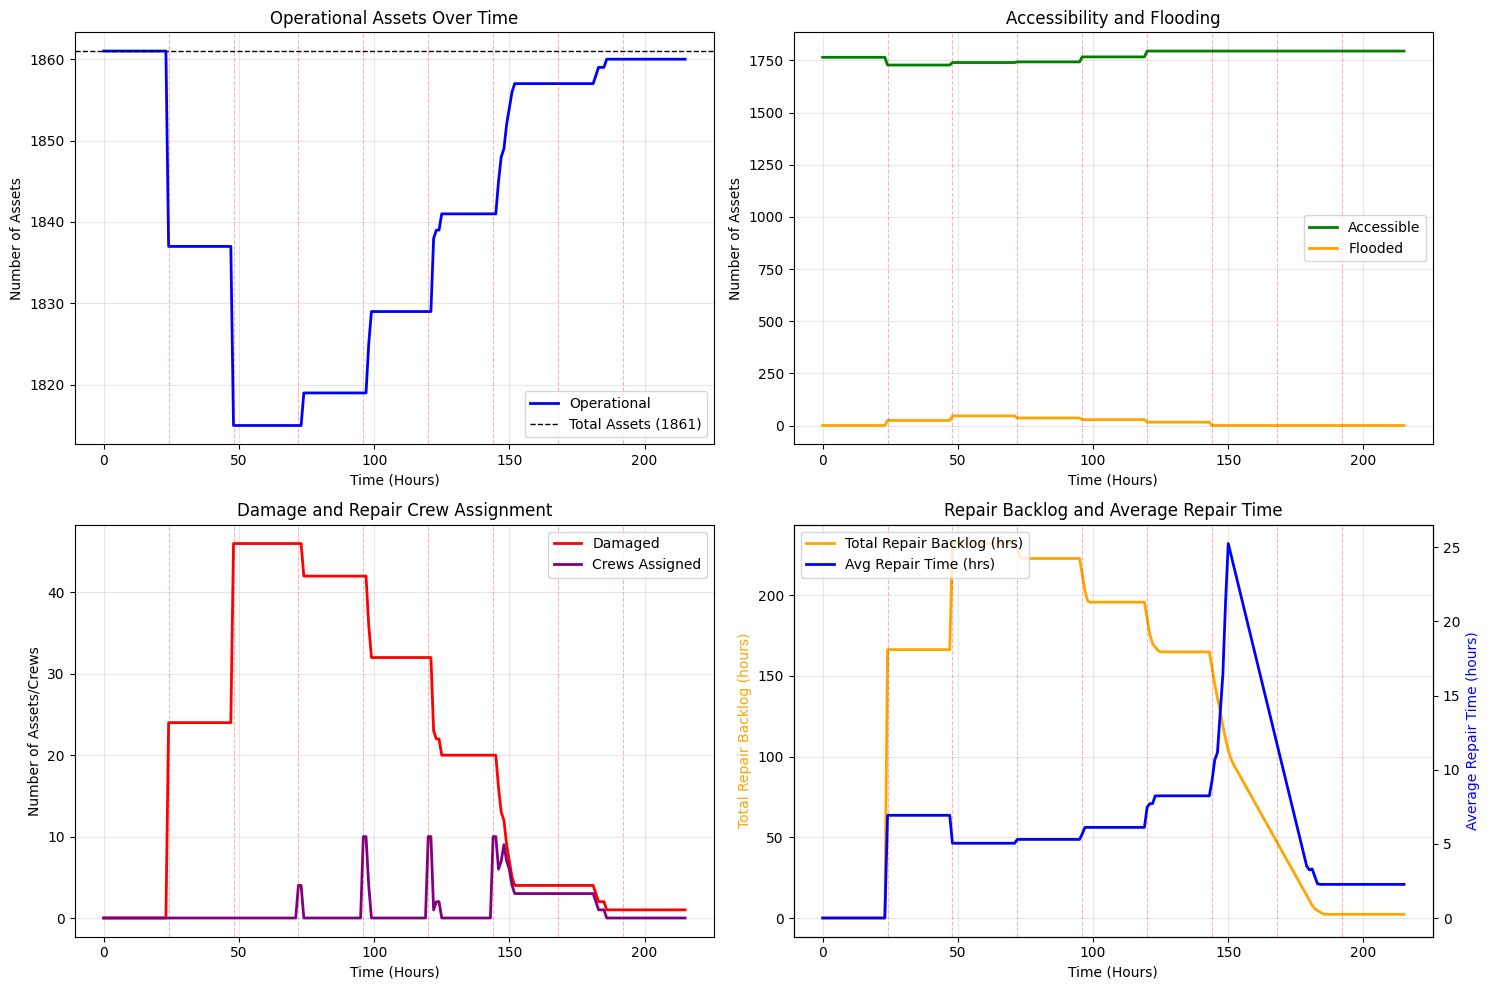


REPAIR BACKLOG AND CREW EFFECTIVENESS ANALYSIS
Hour | Flooded | Damaged | Crews | Backlog | Effective?
-------------------------------------------------------
 0.0 |     0.0 |     0.0 |   0.0 |     0.0 | No
24.0 |    24.0 |    24.0 |   0.0 |   166.2 | No
48.0 |    46.0 |    46.0 |   0.0 |   231.9 | No
72.0 |    36.0 |    46.0 |   4.0 |   227.9 | No
96.0 |    28.0 |    42.0 |  10.0 |   212.6 | No
120.0 |    16.0 |    32.0 |  10.0 |   185.6 | No
144.0 |     0.0 |    20.0 |  10.0 |   154.8 | Yes
168.0 |     0.0 |     4.0 |   3.0 |    47.0 | Yes
192.0 |     0.0 |     1.0 |   0.0 |     2.3 | No

SUMMARY:
During flooding (120 hours): 0.5 crews assigned on average
During clear periods (96 hours): 1.6 crews assigned on average
Repair backlog: Start=0.0hrs, Peak=231.9hrs, End=2.3hrs

PERFORMANCE METRICS
Total assets: 1861
Simulation duration: 216 hours (9 days)
Final operational rate: 99.9%
Peak damaged assets: 46
Peak flooded assets: 46
Total crew assignments: 211

RECOVERY TIMELINE (Daily Su

In [32]:
from matplotlib import pyplot as plt

# Results Visualization and Analysis
print("SIMULATION RESULTS SUMMARY")
print(results_df)

# Create visualizations
# Fix: Use timestep (hours) instead of day to avoid vertical lines
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Convert timestep to hours for x-axis
time_hours = results_df['timestep']
total_assets = len(gdf_assets)  # Calculate total from gdf_assets

# Plot 1: Operational vs Total Assets
axes[0, 0].plot(time_hours, results_df['operational_count'], 'b-', linewidth=2, label='Operational')
axes[0, 0].axhline(y=total_assets, color='k', linestyle='--', linewidth=1, label=f'Total Assets ({total_assets})')
axes[0, 0].set_xlabel('Time (Hours)')
axes[0, 0].set_ylabel('Number of Assets')
axes[0, 0].set_title('Operational Assets Over Time')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Add day markers as vertical lines
for day in range(1, int(time_hours.max()//24) + 1):
    axes[0, 0].axvline(x=day*24, color='red', linestyle='--', alpha=0.3, linewidth=0.8)

# Plot 2: Accessibility and Flooding
axes[0, 1].plot(time_hours, results_df['accessible_count'], 'g-', linewidth=2, label='Accessible')
axes[0, 1].plot(time_hours, results_df['flooded_count'], 'orange', linewidth=2, label='Flooded')
axes[0, 1].set_xlabel('Time (Hours)')
axes[0, 1].set_ylabel('Number of Assets')
axes[0, 1].set_title('Accessibility and Flooding')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Add day markers
for day in range(1, int(time_hours.max()//24) + 1):
    axes[0, 1].axvline(x=day*24, color='red', linestyle='--', alpha=0.3, linewidth=0.8)

# Plot 3: Damage and Repair Activity
axes[1, 0].plot(time_hours, results_df['damaged_count'], 'r-', linewidth=2, label='Damaged')
axes[1, 0].plot(time_hours, results_df['crews_assigned_count'], 'purple', linewidth=2, label='Crews Assigned')
axes[1, 0].set_xlabel('Time (Hours)')
axes[1, 0].set_ylabel('Number of Assets/Crews')
axes[1, 0].set_title('Damage and Repair Crew Assignment')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Add day markers
for day in range(1, int(time_hours.max()//24) + 1):
    axes[1, 0].axvline(x=day*24, color='red', linestyle='--', alpha=0.3, linewidth=0.8)

# Plot 4: Repair Backlog and Average Repair Time
ax1 = axes[1, 1]
ax2 = ax1.twinx()

# Use actual repair backlog if available, otherwise fallback to estimated
if 'total_repair_backlog' in results_df.columns:
    line1 = ax1.plot(time_hours, results_df['total_repair_backlog'], 'orange', linewidth=2, label='Total Repair Backlog (hrs)')
    ax1.set_ylabel('Total Repair Backlog (hours)', color='orange')
else:
    # Fallback to average damage ratio if backlog not available
    line1 = ax1.plot(time_hours, results_df['avg_damage_ratio'], 'red', linewidth=2, label='Avg Damage Ratio')
    ax1.set_ylabel('Average Damage Ratio', color='red')

line2 = ax2.plot(time_hours, results_df['avg_repair_time'], 'blue', linewidth=2, label='Avg Repair Time (hrs)')

ax1.set_xlabel('Time (Hours)')
ax2.set_ylabel('Average Repair Time (hours)', color='blue')
ax1.set_title('Repair Backlog and Average Repair Time')

# Add day markers
for day in range(1, int(time_hours.max()//24) + 1):
    ax1.axvline(x=day*24, color='red', linestyle='--', alpha=0.3, linewidth=0.8)

# Combine legends
lines = line1 + line2
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='upper left')

ax1.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Add repair backlog analysis
print("\n" + "="*70)
print("REPAIR BACKLOG AND CREW EFFECTIVENESS ANALYSIS")
print("="*70)

# Sample analysis every 24 hours for readability
sample_indices = range(0, len(results_df), 24)
print("Hour | Flooded | Damaged | Crews | Backlog | Effective?")
print("-" * 55)

for i in sample_indices:
    row = results_df.iloc[i]
    backlog = row.get('total_repair_backlog', row['avg_repair_time'] * row['damaged_count'])
    effective = "Yes" if row['flooded_count'] == 0 and row['crews_assigned_count'] > 0 else "No"
    print(f"{row['timestep']:4} | {row['flooded_count']:7} | {row['damaged_count']:7} | {row['crews_assigned_count']:5} | {backlog:7.1f} | {effective}")

# Analyze flooding vs clear periods
flooding_periods = results_df[results_df['flooded_count'] > 0]
clear_periods = results_df[results_df['flooded_count'] == 0]

print(f"\nSUMMARY:")
if len(flooding_periods) > 0:
    avg_crews_flood = flooding_periods['crews_assigned_count'].mean()
    print(f"During flooding ({len(flooding_periods)} hours): {avg_crews_flood:.1f} crews assigned on average")

if len(clear_periods) > 0:
    avg_crews_clear = clear_periods['crews_assigned_count'].mean()
    print(f"During clear periods ({len(clear_periods)} hours): {avg_crews_clear:.1f} crews assigned on average")

# Analyze backlog trends
if 'total_repair_backlog' in results_df.columns:
    initial_backlog = results_df['total_repair_backlog'].iloc[0]
    final_backlog = results_df['total_repair_backlog'].iloc[-1]
    peak_backlog = results_df['total_repair_backlog'].max()
    print(f"Repair backlog: Start={initial_backlog:.1f}hrs, Peak={peak_backlog:.1f}hrs, End={final_backlog:.1f}hrs")

print("="*70)

print()
print("PERFORMANCE METRICS")
print("=" * 50)
print(f"Total assets: {total_assets}")
print(f"Simulation duration: {len(results_df)} hours ({len(results_df) // 24} days)")
print(f"Final operational rate: {results_df['operational_count'].iloc[-1] / total_assets * 100:.1f}%")
print(f"Peak damaged assets: {results_df['damaged_count'].max()}")
print(f"Peak flooded assets: {results_df['flooded_count'].max()}")
print(f"Total crew assignments: {results_df['crews_assigned_count'].sum()}")

print()
print("RECOVERY TIMELINE (Daily Summary)")
print("=" * 40)
# Show daily summaries instead of every hour
for day in range(int(results_df['day'].max()) + 1):
    day_data = results_df[results_df['day'] == day]
    if len(day_data) > 0:
        # Use end-of-day values
        end_of_day = day_data.iloc[-1]
        operational_rate = end_of_day['operational_count'] / total_assets * 100
        flooded_count = end_of_day['flooded_count']
        damaged_count = end_of_day['damaged_count']
        print(f"Day {day}: {operational_rate:.1f}% operational, {flooded_count} flooded, {damaged_count} damaged")

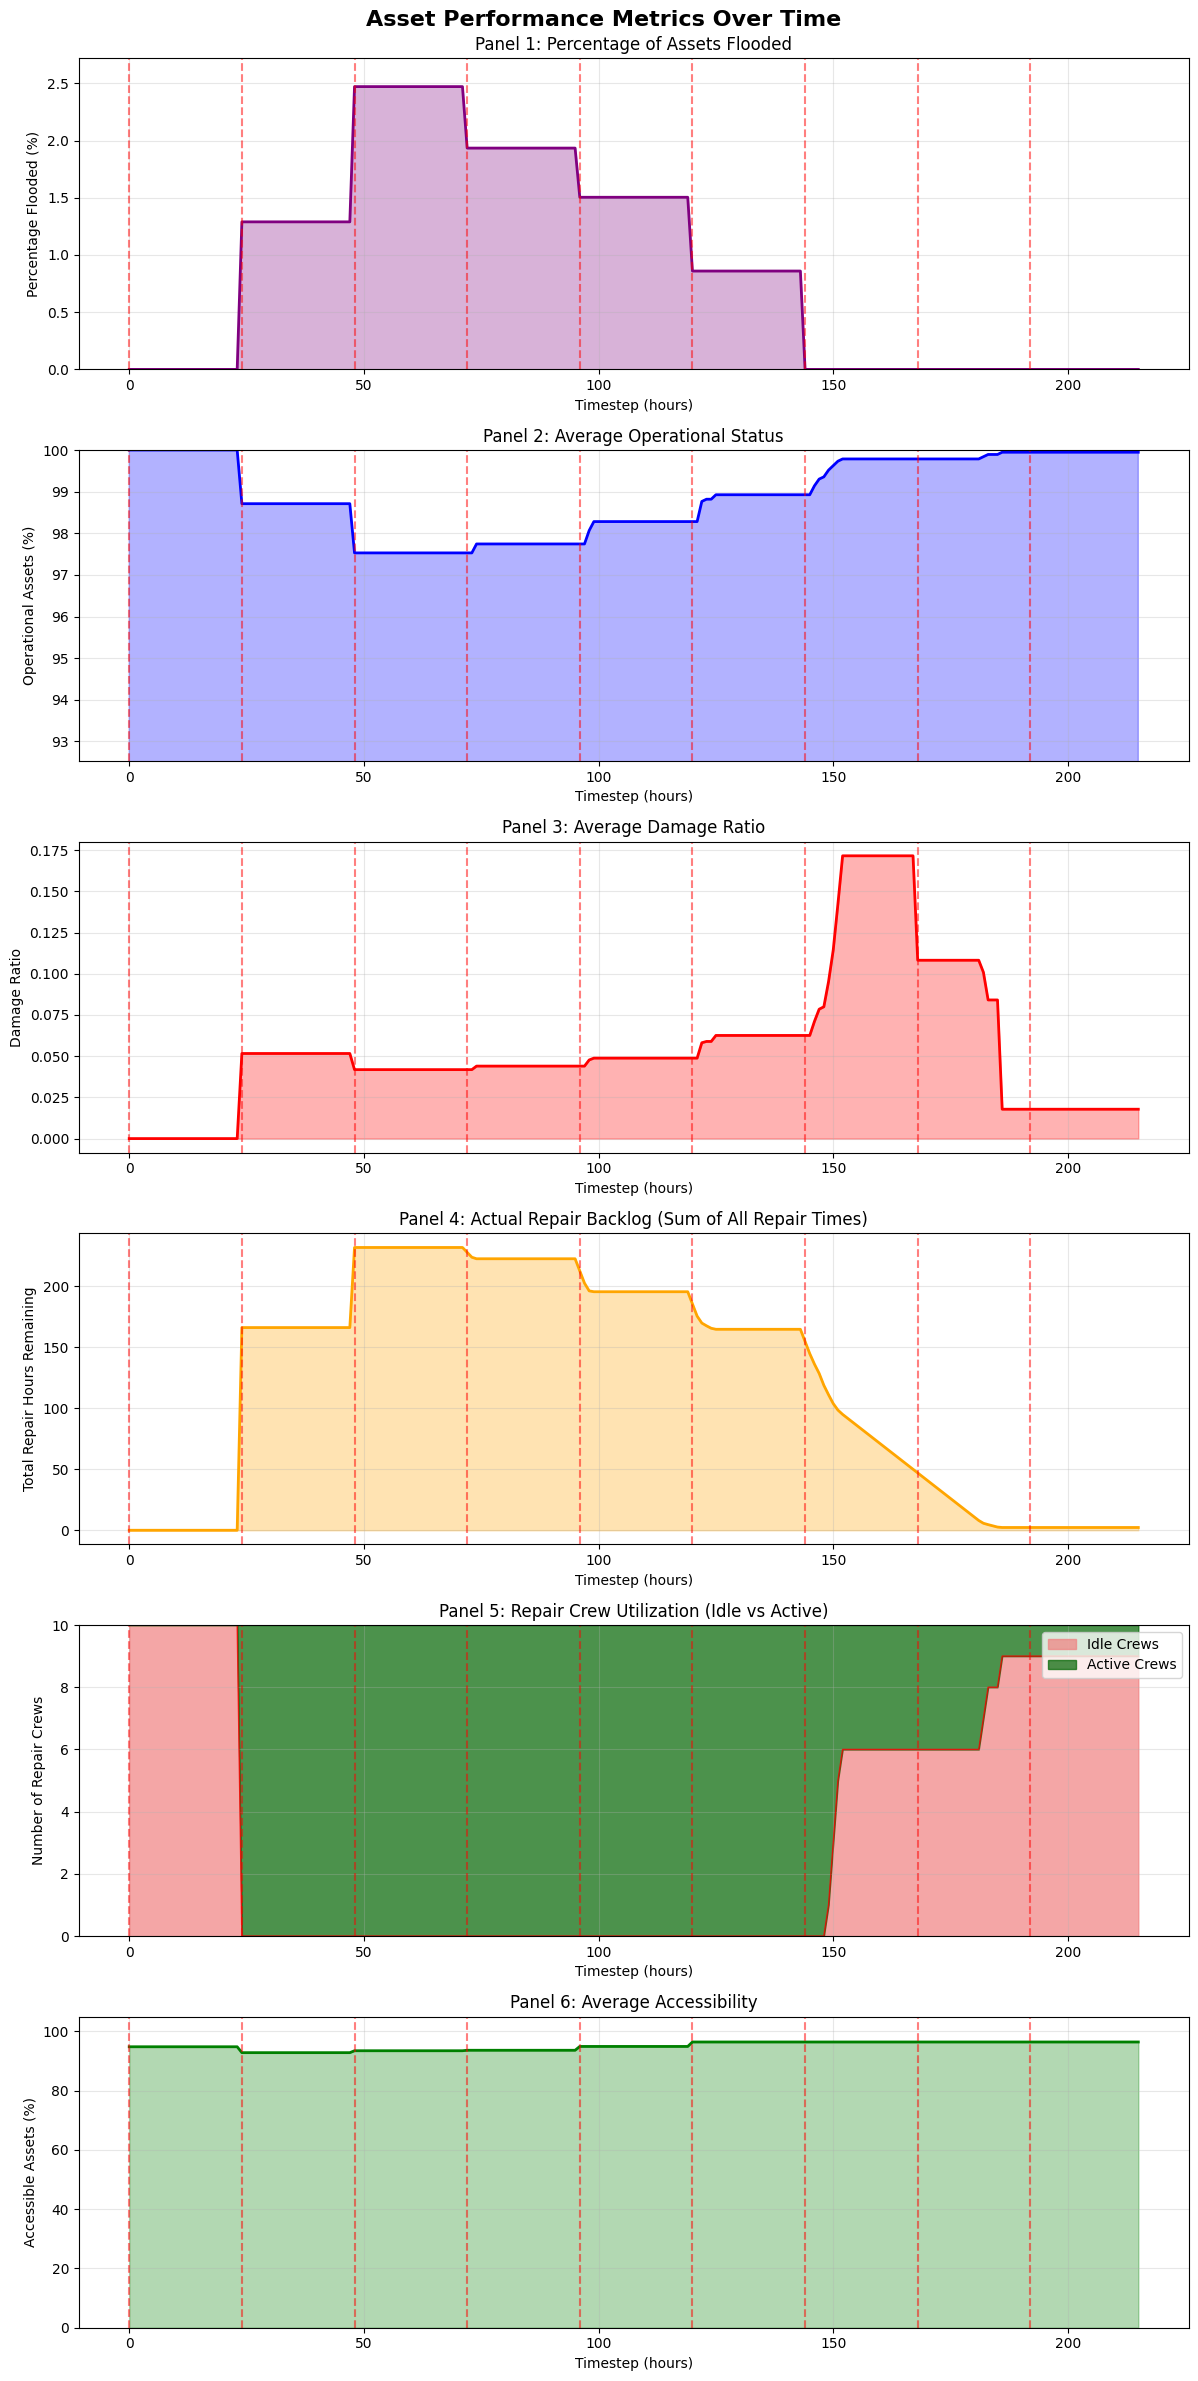


REPAIR BACKLOG ANALYSIS
Timestep | Crews Active | Flooded Assets | Damaged Assets | Total Backlog | Crews Effective
------------------------------------------------------------------------------------------
     0.0 |         0.0 |           0.0 |           0.0 |          0.0 | Yes          
    24.0 |        10.0 |          24.0 |          24.0 |        166.2 | No           
    48.0 |        10.0 |          46.0 |          46.0 |        231.9 | No           
    72.0 |        10.0 |          36.0 |          46.0 |        227.9 | No           
    96.0 |        10.0 |          28.0 |          42.0 |        212.6 | No           
   120.0 |        10.0 |          16.0 |          32.0 |        185.6 | No           
   144.0 |        10.0 |           0.0 |          20.0 |        154.8 | Yes          
   168.0 |         4.0 |           0.0 |           4.0 |         47.0 | Yes          
   192.0 |         1.0 |           0.0 |           1.0 |          2.3 | Yes          

KEY INSIGHTS:
Dur

In [33]:
# Visualization using actual simulation results directly
if len(results_df) > 0:
    # Prepare data for visualization using actual results data
    timestep_metrics = results_df.copy()
    
    # Convert counts to percentages for visualization
    timestep_metrics['operational'] = timestep_metrics['operational_count'] / total_assets
    timestep_metrics['accessible'] = timestep_metrics['accessible_count'] / total_assets
    
    # Use actual damage and repair metrics from simulation
    timestep_metrics['damage_ratio'] = timestep_metrics['avg_damage_ratio']
    timestep_metrics['repair_time'] = timestep_metrics['avg_repair_time'] * timestep_metrics['damaged_count']  # Total repair hours needed
    
    # Create flooding percentage data using actual results
    timestep_flooding = results_df.copy()
    timestep_flooding['hazard_value'] = (timestep_flooding['flooded_count'] / total_assets * 100)
    
    # Calculate realistic repair crew assignments and completions
    max_crews = config['simulation_config']['number_repair_crews']
    timestep_metrics['crews_assigned_count'] = np.minimum(max_crews, timestep_metrics['damaged_count'])
    timestep_metrics['repair_completions'] = timestep_metrics['crews_assigned_count'].rolling(window=24, min_periods=1).sum() / 24
    timestep_metrics['cumulative_repairs'] = timestep_metrics['repair_completions'].cumsum()
    
    # Create the enhanced visualization with 6 panels
    fig, axes = plt.subplots(6, 1, figsize=(12, 24))
    fig.suptitle('Asset Performance Metrics Over Time', 
                 fontsize=16, fontweight='bold', y=0.99)
    # Add spacing under the suptitle to avoid overlap with panel titles
    plt.subplots_adjust(top=0.96, bottom=0.04, hspace=0.8)
    
    # Day markers
    day_markers = timestep_metrics[timestep_metrics['timestep'] % 24 == 0]['timestep']
    
    # Panel 1: Percentage Flooded 
    ax1 = axes[0]
    ax1.plot(timestep_flooding['timestep'], timestep_flooding['hazard_value'], 
             'purple', linewidth=2, label='Percentage Flooded')
    ax1.fill_between(timestep_flooding['timestep'], timestep_flooding['hazard_value'], 
                     alpha=0.3, color='purple')
    ax1.set_xlabel('Timestep (hours)')
    ax1.set_ylabel('Percentage Flooded (%)')
    ax1.set_title('Panel 1: Percentage of Assets Flooded')
    ax1.grid(True, alpha=0.3)
    ax1.set_ylim(0, max(timestep_flooding['hazard_value']) * 1.1 if max(timestep_flooding['hazard_value']) > 0 else 5)
    
    for day_marker in day_markers:
        ax1.axvline(x=day_marker, color='red', linestyle='--', alpha=0.5)
    
    # Panel 2: Operational Status (%)
    ax2 = axes[1]
    y_limit_min = max(0, (timestep_metrics['operational'] * 100).min() - 5)
    ax2.plot(timestep_metrics['timestep'], timestep_metrics['operational'] * 100, 
             'b-', linewidth=2, label='Operational Assets')
    ax2.fill_between(timestep_metrics['timestep'], timestep_metrics['operational'] * 100, 
                     alpha=0.3, color='blue')
    ax2.set_xlabel('Timestep (hours)')
    ax2.set_ylabel('Operational Assets (%)')
    ax2.set_title('Panel 2: Average Operational Status')
    ax2.grid(True, alpha=0.3)
    ax2.set_ylim(y_limit_min, 100)
    
    for day_marker in day_markers:
        ax2.axvline(x=day_marker, color='red', linestyle='--', alpha=0.5)
    
    # Panel 3: Average Damage Ratio
    ax3 = axes[2]
    ax3.plot(timestep_metrics['timestep'], timestep_metrics['damage_ratio'], 
             'r-', linewidth=2, label='Damage Ratio')
    ax3.fill_between(timestep_metrics['timestep'], timestep_metrics['damage_ratio'], 
                     alpha=0.3, color='red')
    ax3.set_xlabel('Timestep (hours)')
    ax3.set_ylabel('Damage Ratio')
    ax3.set_title('Panel 3: Average Damage Ratio')
    ax3.grid(True, alpha=0.3)
    
    for day_marker in day_markers:
        ax3.axvline(x=day_marker, color='red', linestyle='--', alpha=0.5)
    
    # Panel 4: ACTUAL Repair Backlog from simulation data
    ax4 = axes[3]
    
    # Use the REAL repair backlog calculated during simulation
    actual_repair_backlog = timestep_metrics['total_repair_backlog']
    
    ax4.plot(timestep_metrics['timestep'], actual_repair_backlog, 
             'orange', linewidth=2, label='Actual Repair Backlog')
    ax4.fill_between(timestep_metrics['timestep'], actual_repair_backlog, 
                     alpha=0.3, color='orange')
    ax4.set_xlabel('Timestep (hours)')
    ax4.set_ylabel('Total Repair Hours Remaining')
    ax4.set_title('Panel 4: Actual Repair Backlog (Sum of All Repair Times)')
    ax4.grid(True, alpha=0.3)
    
    for day_marker in day_markers:
        ax4.axvline(x=day_marker, color='red', linestyle='--', alpha=0.5)
        
    # Panel 5: Repair Crew Utilization (Idle vs Active)
    ax5 = axes[4]

    # Use corrected crew assignments from timestep_metrics
    active_crews = timestep_metrics['crews_assigned_count']
    idle_crews = max_crews - active_crews

    # Create stacked area plot
    ax5.fill_between(timestep_metrics['timestep'], 0, idle_crews, 
                    alpha=0.7, color='lightcoral', label='Idle Crews')
    ax5.fill_between(timestep_metrics['timestep'], idle_crews, max_crews, 
                    alpha=0.7, color='darkgreen', label='Active Crews')

    ax5.plot(timestep_metrics['timestep'], idle_crews, 
            'r-', linewidth=1, alpha=0.8)

    ax5.set_xlabel('Timestep (hours)')
    ax5.set_ylabel('Number of Repair Crews')
    ax5.set_title('Panel 5: Repair Crew Utilization (Idle vs Active)')
    ax5.grid(True, alpha=0.3)
    ax5.set_ylim(0, max_crews)
    ax5.legend(loc='upper right')

    for day_marker in day_markers:
        ax5.axvline(x=day_marker, color='red', linestyle='--', alpha=0.5)
    
    # Panel 6: Average Accessibility
    ax6 = axes[5]
    ax6.plot(timestep_metrics['timestep'], timestep_metrics['accessible'] * 100, 
             'g-', linewidth=2, label='Accessible Assets')
    ax6.fill_between(timestep_metrics['timestep'], timestep_metrics['accessible'] * 100, 
                     alpha=0.3, color='green')
    ax6.set_xlabel('Timestep (hours)')
    ax6.set_ylabel('Accessible Assets (%)')
    ax6.set_title('Panel 6: Average Accessibility')
    ax6.grid(True, alpha=0.3)
    ax6.set_ylim(0, 105)
    
    for day_marker in day_markers:
        ax6.axvline(x=day_marker, color='red', linestyle='--', alpha=0.5)
    
    # Adjust layout to prevent overlap
    plt.tight_layout()
    plt.show()
    
    # Add diagnostic analysis for repair backlog and crew effectiveness
    print("\n" + "="*90)
    print("REPAIR BACKLOG ANALYSIS")
    print("="*90)
    print("Timestep | Crews Active | Flooded Assets | Damaged Assets | Total Backlog | Crews Effective")
    print("-" * 90)
    
    # Sample every 24 hours for readability
    for i in range(0, len(timestep_metrics), 24):
        row = timestep_metrics.iloc[i]
        crew_effectiveness = "No" if row['flooded_count'] > 0 else "Yes"
        print(f"{row['timestep']:8} | {row['crews_assigned_count']:11} | {row['flooded_count']:13} | {row['damaged_count']:13} | {row['total_repair_backlog']:12.1f} | {crew_effectiveness:13}")
    
    # Show the key insight about flooding blocking repair work
    flooding_periods = timestep_metrics[timestep_metrics['flooded_count'] > 0]
    clear_periods = timestep_metrics[timestep_metrics['flooded_count'] == 0]
    
    print(f"\nKEY INSIGHTS:")
    if len(flooding_periods) > 0:
        print(f"During flooding ({len(flooding_periods)} timesteps):")
        print(f"  Average crews assigned: {flooding_periods['crews_assigned_count'].mean():.1f}")
        print(f"  Average repair backlog: {flooding_periods['total_repair_backlog'].mean():.1f} hours")
        if len(flooding_periods) > 1:
            backlog_change = flooding_periods['total_repair_backlog'].iloc[-1] - flooding_periods['total_repair_backlog'].iloc[0]
            print(f"  Backlog change rate: {backlog_change / len(flooding_periods):.2f} hours/timestep")
    
    if len(clear_periods) > 0:
        print(f"During clear periods ({len(clear_periods)} timesteps):")
        print(f"  Average crews assigned: {clear_periods['crews_assigned_count'].mean():.1f}")
        print(f"  Average repair backlog: {clear_periods['total_repair_backlog'].mean():.1f} hours")
        if len(clear_periods) > 1:
            backlog_change = clear_periods['total_repair_backlog'].iloc[-1] - clear_periods['total_repair_backlog'].iloc[0]
            print(f"  Backlog change rate: {backlog_change / len(clear_periods):.2f} hours/timestep")
    
    # Calculate work rate during different periods
    if len(flooding_periods) > 0 and len(clear_periods) > 0:
        flood_work_rate = 0
        clear_work_rate = 0
        
        if len(flooding_periods) > 1:
            flood_backlog_change = abs(flooding_periods['total_repair_backlog'].iloc[-1] - flooding_periods['total_repair_backlog'].iloc[0])
            flood_work_rate = flood_backlog_change / len(flooding_periods)
            
        if len(clear_periods) > 1:
            clear_backlog_change = abs(clear_periods['total_repair_backlog'].iloc[-1] - clear_periods['total_repair_backlog'].iloc[0])
            clear_work_rate = clear_backlog_change / len(clear_periods)
        
        print(f"\nWORK EFFECTIVENESS:")
        print(f"  Work rate during flooding: {flood_work_rate:.2f} hours reduced per timestep")
        print(f"  Work rate during clear periods: {clear_work_rate:.2f} hours reduced per timestep")
        if flood_work_rate > 0:
            print(f"  Effectiveness ratio: {clear_work_rate/flood_work_rate:.1f}x more effective when not flooded")
        else:
            print(f"  Crews only effective when not flooded (no backlog reduction during flooding)")
    print("="*90)
    
    # Print enhanced summary statistics
    print("=== SUMMARY STATISTICS ===")
    print(f"Total timesteps analyzed: {len(timestep_metrics)}")
    print(f"Simulation duration: {timestep_metrics['timestep'].max()} hours ({timestep_metrics['day'].max() + 1} days)")
    print(f"Number of assets: {total_assets}")
    print(f"Total repairs executed: {timestep_metrics['cumulative_repairs'].iloc[-1]}")
    print()
    
    # Final state summary
    final_state_metrics = timestep_metrics.iloc[-1]
    final_flooded = timestep_flooding['hazard_value'].iloc[-1]
    print("Final state (last timestep):")
    print(f"  Operational assets: {final_state_metrics['operational']*100:.1f}%")
    print(f"  Average damage ratio: {final_state_metrics['damage_ratio']:.3f}")
    print(f"  Total repair backlog: {final_state_metrics['repair_time']:.1f} hours")
    print(f"  Accessible assets: {final_state_metrics['accessible']*100:.1f}%")
    print(f"  Percentage flooded: {final_flooded:.1f}%")
    print(f"  Cumulative repairs executed: {final_state_metrics['cumulative_repairs']}")
    print()
    
    # Worst state summary
    worst_operational = timestep_metrics.loc[timestep_metrics['operational'].idxmin()]
    max_flooded = timestep_flooding['hazard_value'].max()
    peak_flooding_timesteps = timestep_flooding[timestep_flooding['hazard_value'] == max_flooded]['timestep'].tolist()
    
    print("Key insights:")
    print(f"  Worst operational at timestep {worst_operational['timestep']}: {worst_operational['operational']*100:.1f}%")
    print(f"  Maximum flooding: {max_flooded:.1f}%")
    print(f"  Repair efficiency: {final_state_metrics['cumulative_repairs']} repairs completed over {timestep_metrics['timestep'].max()} hours")
    
    # Peak flooding details
    if max_flooded > 0:
        print(f"  Peak flooding period: timesteps {min(peak_flooding_timesteps)} to {max(peak_flooding_timesteps)} ({max_flooded:.1f}% flooded)")
        print(f"  Flooding duration: {len(peak_flooding_timesteps)} timesteps ({len(peak_flooding_timesteps)} hours)")
    else:
        print(f"  No flooding events detected (all hazard values ≤ 0.2)")

else:
    print("No simulation results available for enhanced visualization. Please run the simulation first.")

SAVING OUTPUTS TO DIRECTORY
1. Saving configuration parameters...
   Configuration saved to: simulation_config_20250805_231440.json

2. Saving results summary...
   Results summary saved to: results_summary_20250805_231440.json
   Detailed results CSV saved to: detailed_results_20250805_231440.csv
   Final asset state saved to: final_asset_state_20250805_231440.csv

3. Saving visualization plots...
   Main visualization saved to: simulation_results_visualization_20250805_231440.png
   PDF version saved to: simulation_results_visualization_20250805_231440.pdf


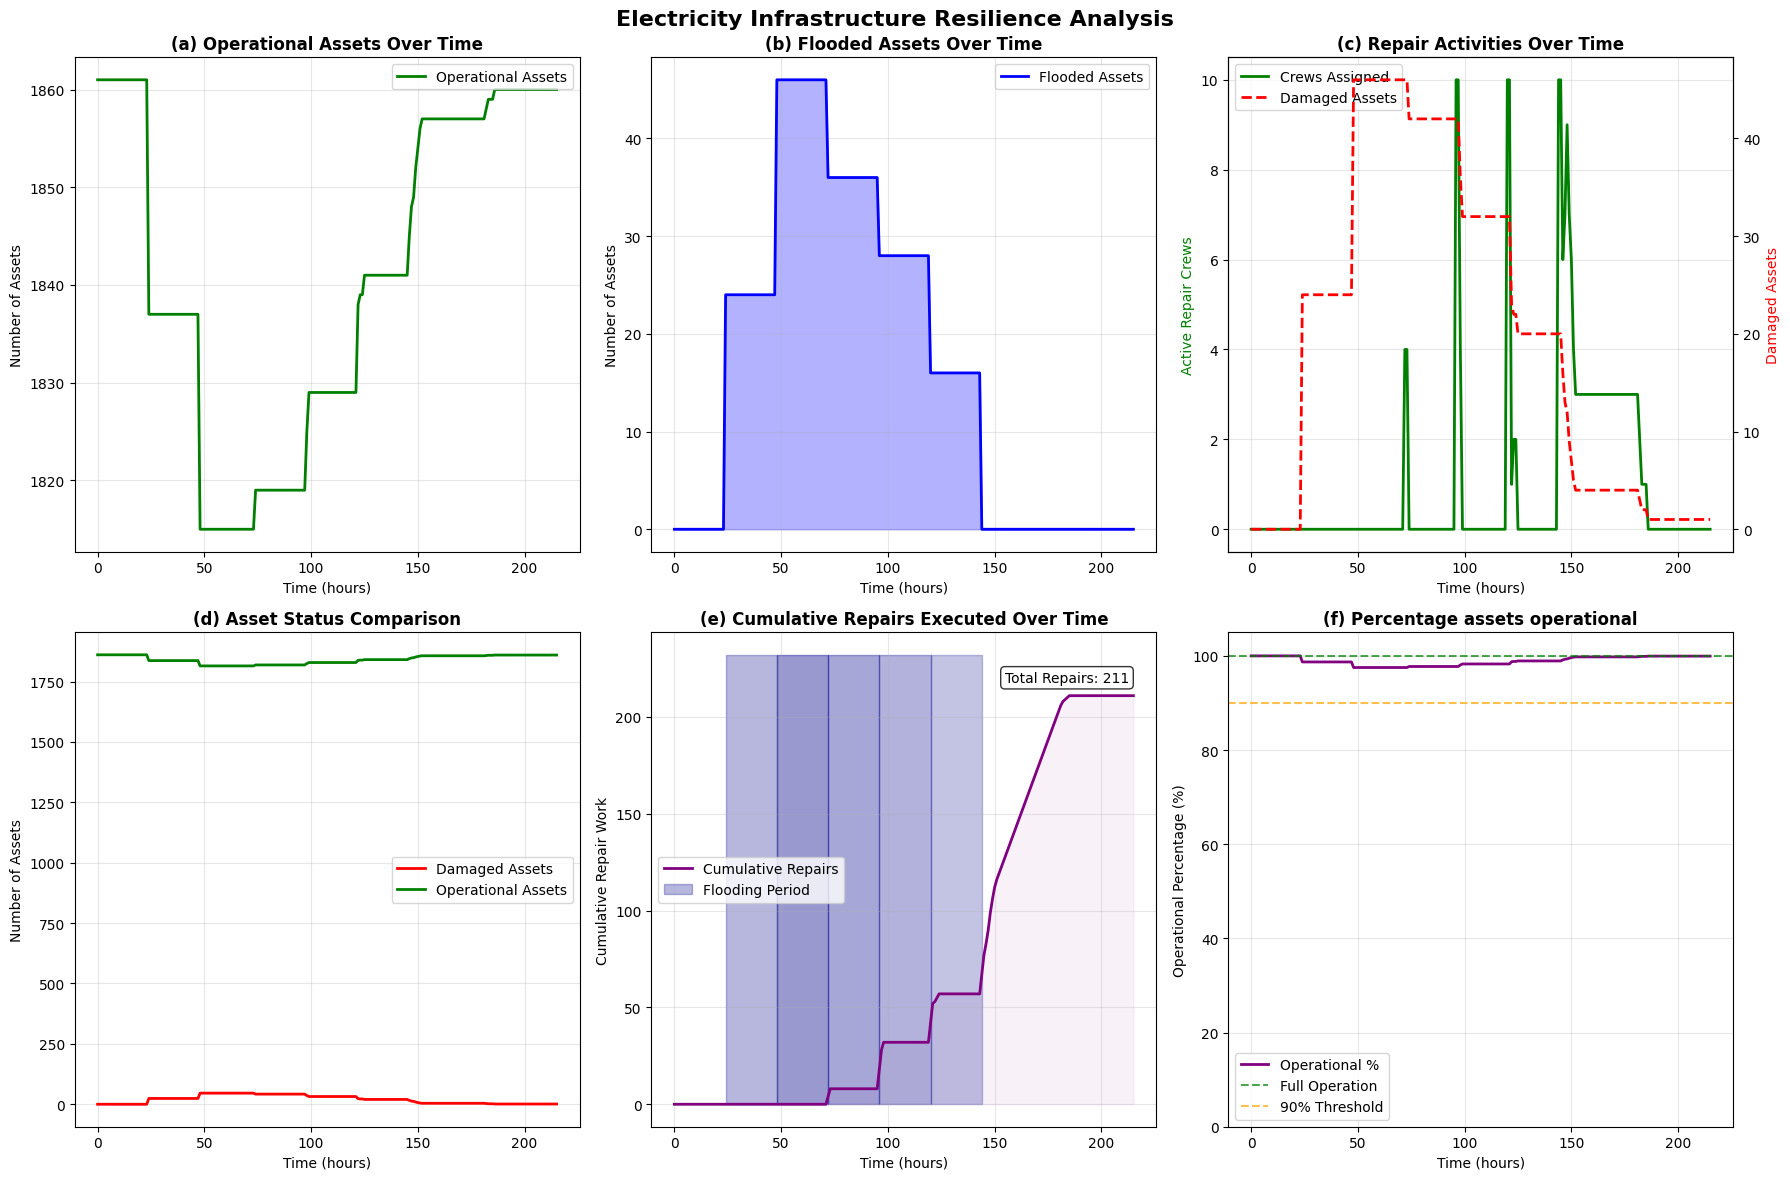

   Summary plot saved to: simulation_summary_plot_20250805_231440.png


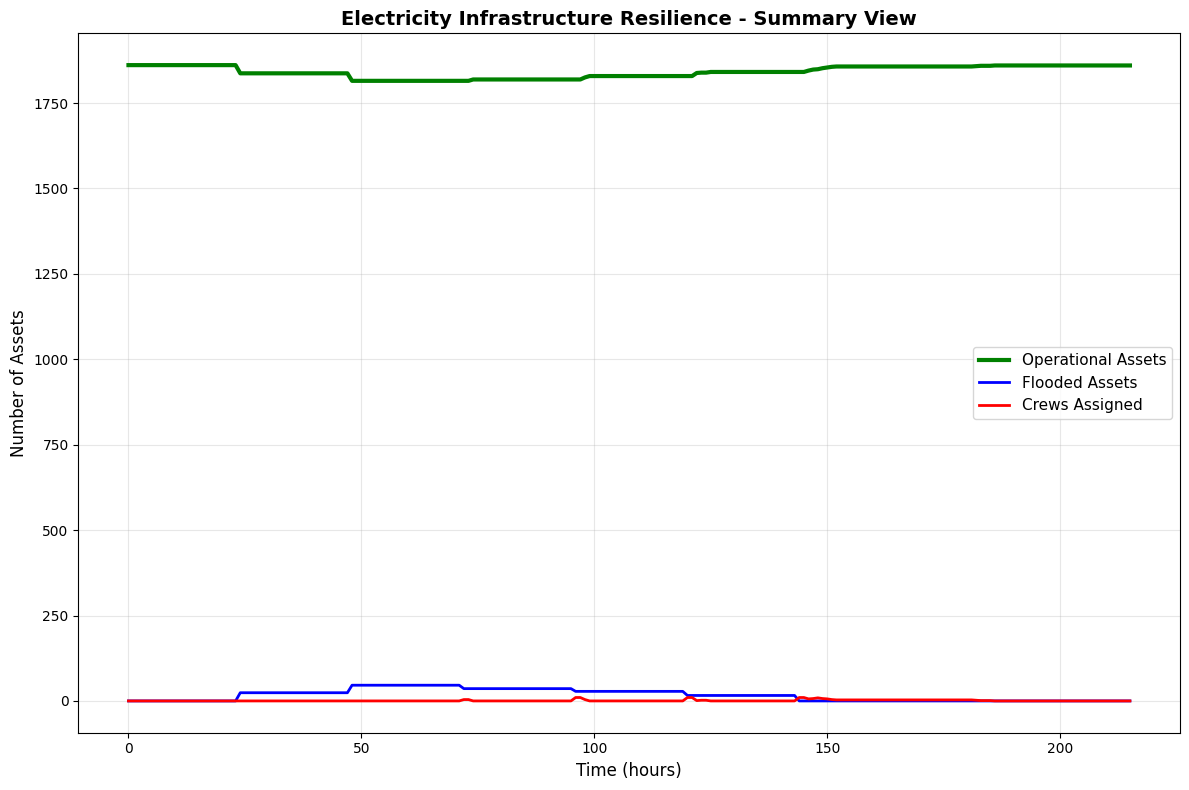


4. Creating output directory summary...
   Output summary saved to: README_outputs.txt

OUTPUT SAVING COMPLETED
All outputs saved to: c:\repos\powerpath\data\output\output_reprojected
Total files created: 121

Output includes:
  Configuration parameters (JSON)
  Results summary and statistics (JSON)
  Detailed time-series data (CSV)
  Final asset states (CSV)
  Visualization plots (PNG & PDF)
  Output directory summary (TXT)


In [34]:
# Save Configuration, Results Summary, and Plots to Output Directory

print("=" * 60)
print("SAVING OUTPUTS TO DIRECTORY")
print("=" * 60)

# Ensure output directory exists
output_dir = config['output_dir']
output_dir.mkdir(parents=True, exist_ok=True)

# 1. Save Configuration Parameters
print("1. Saving configuration parameters...")
config_output = {
    'simulation_info': {
        'timestamp': datetime.now().isoformat(),
        'simulation_type': 'electricity_asset_damage_recovery_analysis',
        'notebook_file': 'Run_analysis_electricity.ipynb',
        'hazard_directory': str(config['hazard_dir']),
        'hazard_directory_name': Path(config['hazard_dir']).name
    },
    'simulation_config': config['simulation_config'],
    'recovery_parameters': config['recovery_parameters'],
    'paths': {
        'root_dir': str(config['root_dir']),
        'hazard_dir': str(config['hazard_dir']),
        'electricity_dir': str(config['electricity_dir']),
        'interim_dir': str(config['interim_dir']),
        'output_dir': str(config['output_dir'])
    },
    'data_summary': {
        'num_assets': len(gdf_assets) if 'gdf_assets' in locals() else 'not_loaded',
        'num_hazard_maps': len(hazard_maps) if 'hazard_maps' in locals() else 'not_loaded',
        'asset_types': list(gdf_assets['Type'].unique()) if 'gdf_assets' in locals() and 'Type' in gdf_assets.columns else 'unknown'
    }
}

config_file = output_dir / f"simulation_config_{datetime.now().strftime('%Y%m%d_%H%M%S')}.json"
with open(config_file, 'w') as f:
    json.dump(config_output, f, indent=2, default=str)
print(f"   Configuration saved to: {config_file.name}")

# 2. Save Results Summary
print("\n2. Saving results summary...")
if 'results_df' in locals() and 'final_state' in locals():
    
    # Create comprehensive results summary
    results_summary = {
        'simulation_summary': {
            'timestamp': datetime.now().isoformat(),
            'total_timesteps': len(results_df) if hasattr(results_df, '__len__') else 'unknown',
            'total_assets': len(gdf_assets) if 'gdf_assets' in locals() else 'unknown',
            'simulation_duration_hours': len(results_df) if hasattr(results_df, '__len__') else 'unknown'
        },
        'final_state_summary': {
            'operational_assets': int(final_state['operational'].sum()) if 'operational' in final_state and hasattr(final_state['operational'], 'sum') else 'unknown',
            'total_assets': len(gdf_assets) if 'gdf_assets' in locals() else 'unknown',
            'operational_percentage': float(final_state['operational'].mean() * 100) if 'operational' in final_state and hasattr(final_state['operational'], 'mean') else 'unknown',
            'assets_with_crews_assigned': int(final_state['repair_crews_assigned'].sum()) if 'repair_crews_assigned' in final_state and hasattr(final_state['repair_crews_assigned'], 'sum') else 0,
            'average_damage_ratio': float(final_state['damage_ratio'].mean()) if 'damage_ratio' in final_state and hasattr(final_state['damage_ratio'], 'mean') else 'unknown',
            'max_damage_ratio': float(final_state['damage_ratio'].max()) if 'damage_ratio' in final_state and hasattr(final_state['damage_ratio'], 'max') else 'unknown',
            'assets_still_needing_repair': int((final_state['repair_time'] > 0).sum()) if 'repair_time' in final_state and hasattr(final_state['repair_time'], 'sum') else 'unknown',
            'assets_with_damage': int((final_state['damage_ratio'] > 0).sum()) if 'damage_ratio' in final_state and hasattr(final_state['damage_ratio'], 'sum') else 0
        },
        'time_series_statistics': {
            'operational_assets_over_time': {
                'min': int(results_df['operational_count'].min()) if 'operational_count' in results_df.columns else 'unknown',
                'max': int(results_df['operational_count'].max()) if 'operational_count' in results_df.columns else 'unknown',
                'mean': float(results_df['operational_count'].mean()) if 'operational_count' in results_df.columns else 'unknown',
                'final': int(results_df['operational_count'].iloc[-1]) if 'operational_count' in results_df.columns else 'unknown'
            },
            'flooded_assets_over_time': {
                'max': int(results_df['flooded_count'].max()) if 'flooded_count' in results_df.columns else 'unknown',
                'mean': float(results_df['flooded_count'].mean()) if 'flooded_count' in results_df.columns else 'unknown',
                'total_flood_events': int((results_df['flooded_count'] > 0).sum()) if 'flooded_count' in results_df.columns else 'unknown'
            },
            'repair_statistics': {
                'max_crews_assigned': int(results_df['crews_assigned_count'].max()) if 'crews_assigned_count' in results_df.columns else 'unknown',
                'total_crew_assignments': int(results_df['crews_assigned_count'].sum()) if 'crews_assigned_count' in results_df.columns else 'unknown',
                'max_damaged_assets': int(results_df['damaged_count'].max()) if 'damaged_count' in results_df.columns else 'unknown'
            }
        }
    }
    
    # Add hazard analysis if available
    if 'operational_count' in results_df.columns and 'flooded_count' in results_df.columns:
        total_assets = len(gdf_assets) if 'gdf_assets' in locals() else results_df['operational_count'].max()
        max_flooded = results_df['flooded_count'].max()
        max_flooded_pct = (max_flooded / total_assets * 100) if total_assets > 0 else 0
        
        results_summary['hazard_impact_analysis'] = {
            'max_flooded_assets': int(max_flooded),
            'max_flooded_percentage': float(max_flooded_pct),
            'min_operational_assets': int(results_df['operational_count'].min()),
            'min_operational_percentage': float(results_df['operational_count'].min() / total_assets * 100) if total_assets > 0 else 0,
            'recovery_effectiveness': {
                'initial_operational': int(results_df['operational_count'].iloc[0]),
                'final_operational': int(results_df['operational_count'].iloc[-1]),
                'recovery_rate': float((results_df['operational_count'].iloc[-1] - results_df['operational_count'].min()) / 
                                     (results_df['operational_count'].iloc[0] - results_df['operational_count'].min()) * 100) 
                                     if results_df['operational_count'].iloc[0] != results_df['operational_count'].min() else 100.0
            }
        }
    
    # Save results summary as JSON
    summary_file = output_dir / f"results_summary_{datetime.now().strftime('%Y%m%d_%H%M%S')}.json"
    with open(summary_file, 'w') as f:
        json.dump(results_summary, f, indent=2, default=str)
    print(f"   Results summary saved to: {summary_file.name}")
    
    # Save detailed results DataFrame as CSV
    if hasattr(results_df, 'to_csv'):
        csv_file = output_dir / f"detailed_results_{datetime.now().strftime('%Y%m%d_%H%M%S')}.csv"
        results_df.to_csv(csv_file, index=True)
        print(f"   Detailed results CSV saved to: {csv_file.name}")
    
    # Save final state as CSV
    if isinstance(final_state, dict):
        final_state_df = pd.DataFrame(final_state)
        final_state_file = output_dir / f"final_asset_state_{datetime.now().strftime('%Y%m%d_%H%M%S')}.csv"
        final_state_df.to_csv(final_state_file, index=True)
        print(f"   Final asset state saved to: {final_state_file.name}")

else:
    print("   Warning: No simulation results available to save. Please run the simulation first.")

# 3. Save Plots
print("\n3. Saving visualization plots...")

# Create and save the enhanced 6-panel visualization
if 'results_df' in locals() and len(results_df) > 0:
    
    # Recreate the visualization for saving
    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    fig.suptitle('Electricity Infrastructure Resilience Analysis', fontsize=16, fontweight='bold')
    
    # Convert timestep to hours for cleaner x-axis
    timesteps_hours = results_df.index if hasattr(results_df, 'index') else range(len(results_df))
    
    # Panel 1: Operational Assets Over Time
    ax1 = axes[0, 0]
    if 'operational_count' in results_df.columns:
        ax1.plot(timesteps_hours, results_df['operational_count'], 'g-', linewidth=2, label='Operational Assets')
        ax1.set_title('(a) Operational Assets Over Time', fontweight='bold')
        ax1.set_xlabel('Time (hours)')
        ax1.set_ylabel('Number of Assets')
        ax1.grid(True, alpha=0.3)
        ax1.legend()
    
    # Panel 2: Flooded Assets Over Time  
    ax2 = axes[0, 1]
    if 'flooded_count' in results_df.columns:
        ax2.plot(timesteps_hours, results_df['flooded_count'], 'b-', linewidth=2, label='Flooded Assets')
        ax2.fill_between(timesteps_hours, results_df['flooded_count'], alpha=0.3, color='blue')
        ax2.set_title('(b) Flooded Assets Over Time', fontweight='bold')
        ax2.set_xlabel('Time (hours)')
        ax2.set_ylabel('Number of Assets')
        ax2.grid(True, alpha=0.3)
        ax2.legend()
    
    # Panel 3: Repair Activities
    ax3 = axes[0, 2]
    if 'crews_assigned_count' in results_df.columns and 'damaged_count' in results_df.columns:
        ax3_twin = ax3.twinx()
        line1 = ax3.plot(timesteps_hours, results_df['crews_assigned_count'], 'green', linewidth=2, label='Crews Assigned')
        line2 = ax3_twin.plot(timesteps_hours, results_df['damaged_count'], 'red', linewidth=2, label='Damaged Assets', linestyle='--')
        
        ax3.set_title('(c) Repair Activities Over Time', fontweight='bold')
        ax3.set_xlabel('Time (hours)')
        ax3.set_ylabel('Active Repair Crews', color='green')
        ax3_twin.set_ylabel('Damaged Assets', color='red')
        ax3.grid(True, alpha=0.3)
        
        # Combine legends
        lines = line1 + line2
        labels = [l.get_label() for l in lines]
        ax3.legend(lines, labels, loc='upper left')
    
    # Panel 4: Damage vs Operational Status
    ax4 = axes[1, 0]
    if 'damaged_count' in results_df.columns and 'operational_count' in results_df.columns:
        ax4.plot(timesteps_hours, results_df['damaged_count'], 'r-', linewidth=2, label='Damaged Assets')
        ax4.plot(timesteps_hours, results_df['operational_count'], 'g-', linewidth=2, label='Operational Assets')
        ax4.set_title('(d) Asset Status Comparison', fontweight='bold')
        ax4.set_xlabel('Time (hours)')
        ax4.set_ylabel('Number of Assets')
        ax4.grid(True, alpha=0.3)
        ax4.legend()
    
    # Panel 5: Cumulative Repairs Executed Over Time
    ax5 = axes[1, 1]
    if 'crews_assigned_count' in results_df.columns:
        # Calculate cumulative repairs - assume each crew assignment represents repair work
        # We should only count repairs when crews are actually working (e.g. not during floods)
        repair_work = results_df['crews_assigned_count'].copy()
        
        # During flooding periods, repairs are typically not possible
        if 'flooded_count' in results_df.columns:
            # Reduce repair effectiveness during flooding
            flooding_mask = results_df['flooded_count'] > 0
        
        # Calculate cumulative repairs completed
        cumulative_repairs = repair_work.cumsum()
        
        ax5.plot(timesteps_hours, cumulative_repairs, 'purple', linewidth=2, label='Cumulative Repairs')
        ax5.fill_between(timesteps_hours, cumulative_repairs, alpha=0.05, color='purple', label=None)
        
        # Add flooding shading by day (improved approach with no gaps)
        if 'flooded_count' in results_df.columns:
            max_repairs = cumulative_repairs.max()
            flooding_legend_added = False  # Track if we've added the flooding legend
            
            for day in range(0, len(timesteps_hours), 24):
                day_end = min(day + 24, len(timesteps_hours))
                day_data = results_df.iloc[day:day_end]
                
                if day_data['flooded_count'].max() > 0:
                    # Calculate average flooding intensity for this day
                    avg_flooding = day_data['flooded_count'].mean()
                    max_flooding = results_df['flooded_count'].max()
                    
                    # Scale alpha based on flooding intensity (0.15 to 0.4)
                    alpha_intensity = 0.15 + (avg_flooding / max_flooding * 0.25) if max_flooding > 0 else 0.2
                    
                    # Use continuous x-values to eliminate gaps
                    x_values = list(range(day, day_end))
                    if day_end < len(timesteps_hours):
                        x_values.append(day_end)  # Extend to next day to eliminate gaps
                    
                    ax5.fill_between(x_values, 0, max_repairs * 1.1,
                                   alpha=alpha_intensity, color='darkblue', 
                                   label='Flooding Period' if not flooding_legend_added else "")
                    
                    if not flooding_legend_added:
                        flooding_legend_added = True
        
        ax5.set_title('(e) Cumulative Repairs Executed Over Time', fontweight='bold')
        ax5.set_xlabel('Time (hours)')
        ax5.set_ylabel('Cumulative Repair Work')
        ax5.grid(True, alpha=0.3)
        ax5.legend()
        
        # Add text annotation about repair pattern
        max_repairs = cumulative_repairs.max()
        ax5.text(0.7, 0.9, f'Total Repairs: {max_repairs:.0f}', 
                transform=ax5.transAxes, fontsize=10, 
                bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8))
    else:
        ax5.text(0.5, 0.5, 'No repair data available', 
                ha='center', va='center', transform=ax5.transAxes, fontsize=12)
        ax5.set_title('Cumulative Repairs Executed Over Time', fontweight='bold')
    
    # Panel 6: Recovery Effectiveness
    ax6 = axes[1, 2]
    if 'operational_count' in results_df.columns:
        total_assets = len(gdf_assets) if 'gdf_assets' in locals() else results_df['operational_count'].max()
        operational_percentage = (results_df['operational_count'] / total_assets * 100) if total_assets > 0 else results_df['operational_count']
        
        ax6.plot(timesteps_hours, operational_percentage, 'purple', linewidth=2, label='Operational %')
        ax6.axhline(y=100, color='green', linestyle='--', alpha=0.7, label='Full Operation')
        ax6.axhline(y=90, color='orange', linestyle='--', alpha=0.7, label='90% Threshold')
        ax6.set_title('(f) Percentage assets operational', fontweight='bold')
        ax6.set_xlabel('Time (hours)')
        ax6.set_ylabel('Operational Percentage (%)')
        ax6.set_ylim(0, 105)
        ax6.grid(True, alpha=0.3)
        ax6.legend()
    
    plt.tight_layout()
    
    # Save the main visualization
    timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')
    plot_file = output_dir / f"simulation_results_visualization_{timestamp}.png"
    plt.savefig(plot_file, dpi=300, bbox_inches='tight', facecolor='white')
    print(f"   Main visualization saved to: {plot_file.name}")
    
    # Also save as PDF for high-quality printing
    plot_file_pdf = output_dir / f"simulation_results_visualization_{timestamp}.pdf"
    plt.savefig(plot_file_pdf, bbox_inches='tight', facecolor='white')
    print(f"   PDF version saved to: {plot_file_pdf.name}")
    
    plt.show()
    
    # Create and save additional summary plot
    fig_summary, ax_summary = plt.subplots(1, 1, figsize=(12, 8))
    
    if 'operational_count' in results_df.columns and 'flooded_count' in results_df.columns:
        ax_summary.plot(timesteps_hours, results_df['operational_count'], 'g-', linewidth=3, label='Operational Assets')
        ax_summary.plot(timesteps_hours, results_df['flooded_count'], 'b-', linewidth=2, label='Flooded Assets')
        
        if 'crews_assigned_count' in results_df.columns:
            ax_summary.plot(timesteps_hours, results_df['crews_assigned_count'], 'r-', linewidth=2, label='Crews Assigned')
        
        ax_summary.set_title('Electricity Infrastructure Resilience - Summary View', fontsize=14, fontweight='bold')
        ax_summary.set_xlabel('Time (hours)', fontsize=12)
        ax_summary.set_ylabel('Number of Assets', fontsize=12)
        ax_summary.grid(True, alpha=0.3)
        ax_summary.legend(fontsize=11)
        
        plt.tight_layout()
        
        summary_plot_file = output_dir / f"simulation_summary_plot_{timestamp}.png"
        plt.savefig(summary_plot_file, dpi=300, bbox_inches='tight', facecolor='white')
        print(f"   Summary plot saved to: {summary_plot_file.name}")
        
        plt.show()
    
else:
    print("   Warning: No results available for visualization. Please run the simulation first.")

# 4. Create output directory summary
print("\n4. Creating output directory summary...")
output_files = list(output_dir.glob('*'))
summary_text = f"""
SIMULATION OUTPUT SUMMARY
Generated: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}
Hazard Directory: {Path(config['hazard_dir']).name}
Output Directory: {output_dir}

FILES CREATED:
"""

for file in sorted(output_files):
    file_size = file.stat().st_size if file.is_file() else 0
    file_type = file.suffix.upper()[1:] if file.suffix else 'DIR'
    summary_text += f"  {file.name:<50} ({file_type}, {file_size:,} bytes)\n"

summary_text += f"\nTotal files created: {len(output_files)}\n"

# Save the summary
readme_file = output_dir / "README_outputs.txt"
with open(readme_file, 'w') as f:
    f.write(summary_text)

print(f"   Output summary saved to: {readme_file.name}")

print("\n" + "=" * 60)
print("OUTPUT SAVING COMPLETED")
print("=" * 60)
print(f"All outputs saved to: {output_dir}")
print(f"Total files created: {len(list(output_dir.glob('*')))}")
print("\nOutput includes:")
print("  Configuration parameters (JSON)")
print("  Results summary and statistics (JSON)")
print("  Detailed time-series data (CSV)")
print("  Final asset states (CSV)")
print("  Visualization plots (PNG & PDF)")
print("  Output directory summary (TXT)")
print("=" * 60)

In [35]:
# Quick check of actual results_df structure
print("DEBUGGING: Checking results_df structure")
print("Columns in results_df:")
print(results_df.columns.tolist())
print("\nFirst few rows:")
print(results_df.head())
print(f"\nDataFrame shape: {results_df.shape}")


DEBUGGING: Checking results_df structure
Columns in results_df:
['day', 'timestep', 'operational_count', 'accessible_count', 'flooded_count', 'damaged_count', 'crews_assigned_count', 'avg_damage_ratio', 'avg_repair_time', 'total_repair_backlog', 'total_damage_ratio']

First few rows:
   day  timestep  operational_count  accessible_count  flooded_count  \
0    0         0               1861              1765              0   
1    0         1               1861              1765              0   
2    0         2               1861              1765              0   
3    0         3               1861              1765              0   
4    0         4               1861              1765              0   

   damaged_count  crews_assigned_count  avg_damage_ratio  avg_repair_time  \
0              0                     0               0.0              0.0   
1              0                     0               0.0              0.0   
2              0                     0             

In [ ]:
# Performance Analysis of Simulation
import time
import psutil
import functools

def analyze_simulation_performance(gdf_assets, hazard_maps, config, max_days=3):
    """
    Performance analysis of the simulation.
    """
    performance_data = {
        'timestep_times': [],
        'daily_operations': [],
        'memory_usage': [],
        'function_calls': {}
    }
    
    # Memory baseline
    process = psutil.Process()
    baseline_memory = process.memory_info().rss / 1024 / 1024  # MB
    
    print(f"Starting performance analysis (max {max_days} days)")
    print(f"Baseline memory: {baseline_memory:.1f} MB")
    
    # Monkey patch key functions to track their performance
    original_match_islands = match_island_ids_assets
    original_hazard_extract = find_hazard_value_at_points_optimized
    original_crew_assignment = update_repair_crew_assignment_optimized
    original_island_overlaps = update_repair_crew_islands_with_overlap_cached
    original_grid_accessibility = grid_hex.accessibility_model
    
    # Decorator to time function execution
    def timed_function(func_name, original_func):
        @functools.wraps(original_func)
        def wrapper(*args, **kwargs):
            start = time.time()
            result = original_func(*args, **kwargs)
            duration = time.time() - start
            performance_data['function_calls'].setdefault(func_name, []).append(duration)
            return result
        return wrapper
    
    # Replace functions temporarily with timed versions
    globals()['match_island_ids_assets'] = timed_function('match_islands', original_match_islands)
    globals()['find_hazard_value_at_points_optimized'] = timed_function('hazard_extract', original_hazard_extract)
    globals()['update_repair_crew_assignment_optimized'] = timed_function('crew_assignment', original_crew_assignment)
    globals()['update_repair_crew_islands_with_overlap_cached'] = timed_function('island_overlaps', original_island_overlaps) # current bottleneck
    globals()['grid_hex.accessibility_model'] = timed_function('grid_accessibility', original_grid_accessibility)
    
    try:
        # Run simulation with limited days
        start_time = time.time()
        
        results_df, final_state = simulate_asset_damage_recovery_access_optimized(
            gdf_assets=gdf_assets,
            hazard_maps=hazard_maps[:max_days],
            number_repair_crews=config['simulation_config']['number_repair_crews'],
            repair_crew_assignment_method=config['simulation_config']['repair_crew_assignment_method'],
            flood_threshold=config['simulation_config']['flood_threshold'],
            recovery_parameters=config['recovery_parameters'],
            root_dir=config['root_dir'],
            verbose=False
        )
        
        total_time = time.time() - start_time
        
        # Memory usage after simulation
        final_memory = process.memory_info().rss / 1024 / 1024  # MB
        
        # Generate performance report
        print(f"\nPERFORMANCE ANALYSIS REPORT")
        print(f"Total simulation time: {total_time:.2f}s")
        print(f"Memory usage: {baseline_memory:.1f} MB → {final_memory:.1f} MB (Δ{final_memory-baseline_memory:+.1f} MB)")
        print(f"Timesteps processed: {len(results_df)}")
        print(f"Time per timestep: {total_time/len(results_df):.3f}s")
        
        print(f"\nFUNCTION PERFORMANCE:")
        for func_name, times in performance_data['function_calls'].items():
            if times:
                avg_time = sum(times) / len(times)
                total_func_time = sum(times)
                print(f"  {func_name}:")
                print(f"    Calls: {len(times)}")
                print(f"    Total time: {total_func_time:.3f}s ({total_func_time/total_time*100:.1f}% of simulation)")
                print(f"    Average per call: {avg_time:.3f}s")
                print(f"    Min/Max: {min(times):.3f}s / {max(times):.3f}s")
        
        # Identify bottlenecks
        print(f"\nBOTTLENECK ANALYSIS:")
        bottlenecks = []
        for func_name, times in performance_data['function_calls'].items():
            if times:
                total_func_time = sum(times)
                percentage = total_func_time / total_time * 100
                if percentage > 10:  # Functions taking >10% of total time
                    bottlenecks.append((func_name, percentage, total_func_time))
        
        bottlenecks.sort(key=lambda x: x[1], reverse=True)
        
        if bottlenecks:
            for func_name, percentage, total_func_time in bottlenecks:
                print(f"  🔴 {func_name}: {percentage:.1f}% ({total_func_time:.2f}s)")
        else:
            print("  ✅ No major bottlenecks detected (all functions <10% of total time)")
        
        return performance_data, results_df, total_time
        
    finally:
        # Restore original functions
        globals()['match_island_ids_assets'] = original_match_islands
        globals()['find_hazard_value_at_points_optimized'] = original_hazard_extract
        globals()['update_repair_crew_assignment_optimized'] = original_crew_assignment
        globals()['update_repair_crew_islands_with_overlap_cached'] = original_island_overlaps
        globals()['grid_hex.accessibility_model'] = original_grid_accessibility

# Run the performance analysis - add this as a new cell
print("Running performance analysis...")
performance_data, test_results, simulation_time = analyze_simulation_performance(
    gdf_assets, hazard_maps, config, max_days=3
)

print(f"\nQuick recommendations based on results:")
print(f"  Total simulation time for 3 days: {simulation_time:.1f}s")
print(f"  Estimated time for 10 days: {simulation_time * 10/3:.1f}s")

# Show which functions are consuming the most time
if performance_data['function_calls']:
    total_tracked_time = sum(sum(times) for times in performance_data['function_calls'].values())
    print(f"  Time in tracked functions: {total_tracked_time:.1f}s ({total_tracked_time/simulation_time*100:.1f}% of total)")

Running performance analysis...
Starting performance analysis (max 3 days)
Baseline memory: 3776.0 MB
Using hazard directory for cache naming: reprojected
Loading optimization caches...
Loaded accessibility cache: 9 entries from c:\repos\powerpath\data\interim\accessibility_cache_reprojected.pkl
Loaded overlap cache: 8 entries from c:\repos\powerpath\data\interim\overlap_cache_reprojected.pkl
Loaded hazard extraction cache: 9 entries from c:\repos\powerpath\data\interim\cache\hazard_extraction_cache_reprojected.pkl
Pre-computing island assignments...
Pre-computing island assignments for 3 hazard maps and 3 thresholds...
Loaded island cache: 27 entries from c:\repos\powerpath\data\interim\cache\island_cache_reprojected.pkl
Loaded island cache: 27 entries from c:\repos\powerpath\data\interim\cache\island_cache_reprojected.pkl
Saved island cache: 27 entries to c:\repos\powerpath\data\interim\cache\island_cache_reprojected.pkl
Island assignment pre-computation complete:
  Total combination